# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [First Model](#first-cnn)
4. [Hyperparameter Tuning](#hyperparameter-tuning)
5. [Implementation](#implementation)
6. [Model explanation](#shap-analysis)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering

## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

# Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

### Defining Functions

In [2]:
# TODO  :   Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter
from matplotlib.colors import PowerNorm, LogNorm

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 4,
    pad_bottom: int = 4,
    pad_left: int = 1,
    pad_right: int = 1,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def crop_figure(fig, trim_px=0):
    """
    Converts a Matplotlib Figure into an RGB NumPy array and crops pixels
    at all edges. Compatible with Matplotlib 3.8+.
    """
    fig.canvas.draw()
    # Try new API first (Matplotlib 3.8+)
    try:
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)
        # buffer_rgba() liefert ARGB → zu RGB konvertieren
        img = img[..., :3]  
    except AttributeError:
        # Fallback: ältere Matplotlib-Versionen
        w, h = fig.canvas.get_width_height()
        buf = fig.canvas.tostring_rgb()
        img = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 3))

    if trim_px != 0:
        # Pixel abschneiden
        return img[trim_px:-trim_px, trim_px:-trim_px, :]
    else:
        return img

## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=144, trim_px=0, padding=[0,0,0,0], mp=None, intrpl=None, gam=1, sig=0.1):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    Now includes pixel-exact border cropping.
    """

    # 1. Profil auswählen
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return

    # 2. Nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 3. Heatmap-Matrix generieren (z.B. 40×14 → gepaddet)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy(), pad_top=padding[0], pad_bottom=padding[1], pad_left=padding[2], pad_right=padding[3])

    # 4. Eine quadratische Figure erzeugen
    fig = plt.figure(figsize=(1, 1), dpi=pixels)
    ax = fig.add_axes([0, 0, 1, 1])   # axes füllt alles

    # 5. Heatmap plotten
    heatmap_smooth = gaussian_filter(heatmap_data, sigma=sig)

    if intrpl == None:
        intrpl = "nearest"
    else:
        intrpl=intrpl

    ax.imshow(
        heatmap_smooth,
        cmap=mp,                          # 'gray' 'inferno' 'turbo' 'magma'
        origin="upper",
        aspect="auto",
        interpolation=intrpl,               # 'nearest' 'bilinear' 'bicubic' 'lanczos' 'spline16' 'spline36'
        # vmin=np.percentile(heatmap_data, 2),
        # vmax=np.percentile(heatmap_data, 99),
        # norm=LogNorm(),
        norm=PowerNorm(gamma=gam),
    )
    
    # alles ausblenden
    ax.axis("off")

    # 6. In Array rendern → Pixel exakt abschneiden
    cropped = crop_figure(fig, trim_px=trim_px)

    plt.close(fig)  # Original-Figure schließen

    # 7. Ordner anlegen
    os.makedirs(out_dir, exist_ok=True)

    # 8. Output-Dateinamen
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # 9. Als PNG speichern
    import imageio
    imageio.imwrite(filepath, cropped)


## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=144, trim_px=0, max_profiles=None, padding=None, mp=None, intrpl=None, gamma=1, sig=0.1):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels, trim_px=trim_px, padding=padding, mp=mp, intrpl=intrpl, gam=gamma, sig=sig)
    
        
    out_path = Path(out_dir).resolve()
    p = out_path.name
    out_path = out_path / f"__params_for_{p}.txt"

    with open(out_path, "w", encoding="utf-8") as f:
        print(f"size: {pixels}^2 px", file=f)
        print(f"crop: {trim_px}px", file=f)
        print(f"color theme: {mp}", file=f)
        print(f"interpolation: {intrpl}", file=f)
        print(f"gamma: {gamma}", file=f)
        print(f"gaussian strength: {sig}", file=f)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

### Loading Dataset for Plotting Heatmpas

This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,
hence the baselinemodel evaluated those classes 15-17 as insignificant.
Each square represents a real datapoint.

*****

WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.
A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,
WHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.


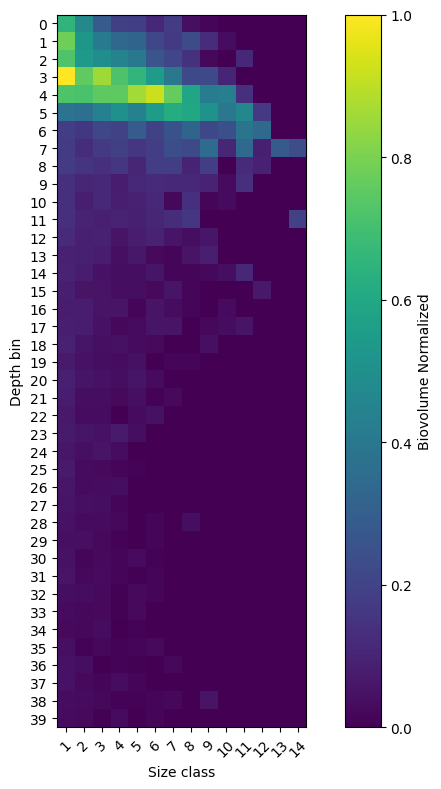

This is a sample of a padded Bioprofile, the way it gets put into the plot function.
⬇︎ This particular padding is static and only an example. ⬇︎


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# TODO  :   Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
import pandas as pd

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()

print(f"="*100)
print("This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,\nhence the baselinemodel evaluated those classes 15-17 as insignificant.\nEach square represents a real datapoint.")
print("\n"+f"*"*5+"\n")
print("WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.")
print("A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,\nWHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.")
print(f"="*100)

plt.show()

print(f"="*100)
print("This is a sample of a padded Bioprofile, the way it gets put into the plot function.\n⬇︎ This particular padding is static and only an example. ⬇︎")
print(f"="*100)
pd.DataFrame(pad_heatmap(heatmap_data)).head()



### Creating Heatmap Plots and Saving them to Files 

In [ ]:
# TODO  :   Converting our input features into heatmaps and export them as an image dataset.

"""
This first part is for redundancy only.
It has been done in a differnet cell before but doesn't always travel.
So we keep it here for 'ease of use'.
"""

# Normalizing the size columns.
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

## --------------------------------------------------------- ##

"""
Here you are able to create the heatmap image output.
    pixels = [48, 144, 240] – are good choices and multiples of 16 (Columns/ Features)
            → 0·1·1·1·1·1·1·1·1·1·1·1·1·1·1·0 (one column padding on either side)

    - df: your dataframe
    - size_cols: how many biovolume size columns should be accounted for
    - out_dir: pick your output dir, this is more for putting out sample data so you don't overwrite your main dataset.
    - pixels: image square size
    - trim_px: cropping image by removing pixels along each side of the square → here you choose how many (by default there is always one line of pixels removed)
    - max_profiles: also more for test purposes
    - sig: sigma parameter of the gaussian filter of the cubic interpolation function

The full ⬇︎ image set creator uses a 240px square with 1px trim resulting in a 238px square heatmap.
The output you find in your '/Data/heatmaps/' directory. 
"""

# Creating and storing the feature-heatmaps in a directory of your choice (default: '/Data/heatmaps').

# TODO : Uncomment for final outpput!! ⬇︎ These are TEST outputs!

#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_10", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl=None, gamma=1, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_11", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_12", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="gray", intrpl="spline36", gamma=1, sig=0.7)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_20", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl=None, gamma=1, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_21", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_22", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="turbo", intrpl="spline36", gamma=1, sig=0.7)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_30", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl=None, gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_31", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8, sig=0.1)
#save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_samples_32", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], intrpl="spline36", gamma=1, sig=0.7)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_10", pixels=45, trim_px=0, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_00", pixels=48, trim_px=1, max_profiles=10, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)

# TODO  : Those are samples
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_00", pixels=45, trim_px=0, padding=[2,3,1,0])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_10", pixels=45, trim_px=0, padding=[2,3,1,0], mp="gray")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_20", pixels=45, trim_px=0, padding=[2,3,1,0], mp="inferno")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_30", pixels=45, trim_px=0, padding=[2,3,1,0], mp="turbo")

# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_01", pixels=48, trim_px=1, padding=[4,4,1,1])
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_02", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_03", pixels=48, trim_px=1, padding=[4,4,1,1], intrpl="bicubic")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_04", pixels=96, trim_px=4, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_05", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_25", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.8)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_26", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.6)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_27", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=0.4)
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_06", pixels=144, trim_px=12, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_07", pixels=192, trim_px=16, padding=[4,4,1,1], intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_34", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
# save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps_35", pixels=48, trim_px=1, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

# =============FINAL full dataset output ================
save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)

# First CNN
-  workflow with small heatmaps & geographical & cluster-stratified split

In [ ]:
# install if necessary:
#pip install imbalanced-learn pillow

In [110]:
#load libraries and set data directories
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Path attributes

DATA_DIR = Path("../Data")
HEATMAP_DIR = DATA_DIR / "heatmaps"

### Functions for: data & heatmap loading, train/test splitting, balancing training data & scaling heatmap pixels

In [111]:

######################## initialize a class with attributes = data directories and files ###############################
# add every new function to this class

class HeatmapCNNClassifier:
    def __init__(self, data_dir=DATA_DIR, heatmap_dir=HEATMAP_DIR):
            self.data_dir = Path(data_dir)
            self.heatmap_dir = Path(heatmap_dir)
            self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val_v2.pkl"
            self.clusters_file = self.data_dir / "Profile_id_to_clusters_4_and_6.pkl"
            self.scaler = StandardScaler()
            self.label_encoder = LabelEncoder()
        
######################## Load data assignments ###############################

def load_data_assignments(self):
    """Load data assignments from pickle files"""
    print("Loading data assignments...")
    
    # Load train/test and cross-validation assignments (DataFrame)
    with open(self.train_test_file, 'rb') as f:
        train_test_df = pickle.load(f)
    
    # Load cluster assignments (DataFrame)
    with open(self.clusters_file, 'rb') as f:
        clusters_df = pickle.load(f)
        clusters_df['cluster'] = clusters_df['cluster_4']       ######## change the number of clusters here as needed
    
    print(f"Train/test DataFrame shape: {train_test_df.shape}")
    print(f"Clusters DataFrame shape: {clusters_df.shape}")
    print(f"Train/test columns: {train_test_df.columns.tolist()}")
    print(f"Clusters columns:  {clusters_df.columns.tolist()}")
    
    # Convert DataFrames to dictionaries for easier lookup
    # Assuming Profile_id is the key column
    self.train_test_cv = {}
    for _, row in train_test_df.iterrows():
        profile_id = row['Profile_id']
        # Create dictionary with remaining columns
        self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
    
    self.clusters = {}
    for _, row in clusters_df.iterrows():
        profile_id = row['Profile_id']
        # Assuming there's a cluster column - let's find it
        cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
        if len(cluster_cols) == 1:
            self.clusters[profile_id] = row[cluster_cols[0]]
        else:
            # If multiple columns, store as dictionary
            self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
    
    print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
    print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
    
    # Show sample data structure
    sample_profile = list(self.train_test_cv.keys())[0]
    print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
    print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")

# add the function to the class
HeatmapCNNClassifier.load_data_assignments = load_data_assignments

######################## Load heatmaps ###############################

def load_heatmaps(self):
    """Load heatmap images and create feature matrices"""
    print("Loading heatmap images...")
    
    # Get list of available heatmap files
    heatmap_files = list(self.heatmap_dir.glob("*.png"))
    print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
    
    if len(heatmap_files) == 0:
        raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
    
    # Extract profile IDs from filenames (remove .png extension)
    available_profile_ids = [f.stem for f in heatmap_files]
    
    # Debug: Show sample filenames and extracted profile IDs
    sample_files = heatmap_files[:5]
    sample_ids = [f.stem for f in sample_files]
    print(f"Sample filenames: {[f.name for f in sample_files]}")
    print(f"Sample extracted profile IDs: {sample_ids}")
    
    # Convert profile IDs to consistent format (strings)
    train_test_ids = set(str(k) for k in self.train_test_cv.keys())
    cluster_ids = set(str(k) for k in self.clusters.keys())
    filename_ids = set(str(id_) for id_ in available_profile_ids)
    
    print(f"Available profile IDs from filenames: {len(filename_ids)}")
    print(f"Profile IDs with train/test data: {len(train_test_ids)}")
    print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
    
    # Find common profile IDs across all data sources
    common_with_train_test = filename_ids & train_test_ids
    common_with_clusters = filename_ids & cluster_ids
    common_all = filename_ids & train_test_ids & cluster_ids
    
    print(f"Files matching train/test IDs: {len(common_with_train_test)}")
    print(f"Files matching cluster IDs: {len(common_with_clusters)}")
    print(f"Files matching all data sources: {len(common_all)}")
    
    if len(common_all) == 0:
        print("\nDEBUGGING: No matching profile IDs found!")
        print("Sample IDs from each source:")
        print(f"Filenames: {list(filename_ids)[:5]}")
        print(f"Train/test:  {list(train_test_ids)[:5]}")
        print(f"Clusters: {list(cluster_ids)[:5]}")
        raise ValueError("No matching profile IDs found between files and metadata")
    
    common_ids = list(common_all)
    print(f"Found {len(common_ids)} profiles with complete data")
    
    # Load images and extract data
    X_data = []
    y_data = []
    profile_ids = []
    data_types = []
    cv_folds = []
    
    # Load a sample image to get dimensions
    sample_profile_id = common_ids[0]
    sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
    sample_img = Image.open(sample_img_path)
    sample_array = np.array(sample_img)
    img_shape = sample_array.shape
    print(f"Image dimensions: {img_shape}")
    
    for profile_id_str in common_ids:
        # Convert string back to original type for dictionary lookup
        # Try both string and original type
        lookup_id = profile_id_str
        for original_id in self.train_test_cv.keys():
            if str(original_id) == profile_id_str:
                lookup_id = original_id
                break
        
        # Load image
        img_path = self.heatmap_dir / f"{profile_id_str}.png"
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Normalize pixel values to [0, 1]
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        
        X_data.append(img_array)
        
        # Extract cluster assignment
        cluster_data = self.clusters[lookup_id]
        if isinstance(cluster_data, dict):
            # If cluster data is a dictionary, assume first value is the cluster
            y_data.append(list(cluster_data.values())[0])
        else:
            y_data.append(cluster_data)
        
        profile_ids.append(profile_id_str)
        data_types.append(self.train_test_cv[lookup_id]['data_type'])
        cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
    
    self.X_data = np.array(X_data)
    self.y_data = np.array(y_data)
    self.profile_ids = np.array(profile_ids)
    self.data_types = np.array(data_types)
    self.cv_folds = np.array(cv_folds)
    
    print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
    print(f"Unique clusters found: {np.unique(self.y_data)}")
    print(f"Data types found: {np.unique(self.data_types)}")
    print(f"CV folds found: {np.unique(self.cv_folds)}")

# add the function to the class
HeatmapCNNClassifier.load_heatmaps = load_heatmaps


######################## Train/test split ###############################

def split_train_test(self):
    """Split data into train and test sets based on pre-defined assignments"""
    print("Splitting data into train and test sets...")
    
    train_mask = self.data_types == 'train'
    test_mask = self.data_types == 'test'
    
    self.X_train = self.X_data[train_mask]
    self.y_train = self.y_data[train_mask]
    self.train_profile_ids = self.profile_ids[train_mask]
    self.train_cv_folds = self.cv_folds[train_mask]
    
    self.X_test = self.X_data[test_mask]
    self.y_test = self.y_data[test_mask]
    self.test_profile_ids = self.profile_ids[test_mask]
    
    print(f"Training set:  {len(self.X_train)} samples")
    print(f"Test set: {len(self.X_test)} samples")
    
    # Encode labels
    self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
    self.y_test_encoded = self.label_encoder.transform(self.y_test)
    self.n_classes = len(self.label_encoder.classes_)
    
    print(f"Number of classes: {self.n_classes}")
    print(f"Classes: {self.label_encoder.classes_}")

# add the function to the class
HeatmapCNNClassifier.split_train_test = split_train_test


######################## Balance classes per fold - SMOTE Tomek link ###############################

def balance_classes_per_fold_SMOTETomek(self):
    """Apply balancing within each CV fold separately"""
    print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds:
        print(f"\nBalancing fold:  {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Check if balancing is needed for this fold
        fold_counts = Counter(y_train_fold)
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            # Reshape data for resampling (flatten images)
            X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
            
            # Apply SMOTETomek
            smote_tomek = SMOTETomek(
                smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                tomek=TomekLinks(),
                random_state=42
            )
            
            X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
            
            # Reshape back to image format
            X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show distribution after balancing
            balanced_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(balanced_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_SMOTETomek = balance_classes_per_fold_SMOTETomek


######################## Balance classes per fold - Oversampling and undersampling ###############################

def balance_classes_per_fold_simple(self):
    """Apply simple over/undersampling to mean cluster size within each CV fold"""
    print("Balancing classes per fold using simple over/undersampling to mean...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds: {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds: 
        print(f"\nBalancing fold: {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Calculate cluster distribution
        fold_counts = Counter(y_train_fold)
        total_samples = len(y_train_fold)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = y_train_fold == cluster_idx
                X_cluster = X_train_fold[cluster_mask]
                y_cluster = y_train_fold[cluster_mask]
                
                current_count = len(X_cluster)
                cluster_name = self.label_encoder.classes_[cluster_idx]
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_name}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_name}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_name}:  {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            X_train_balanced = np.vstack(X_balanced_list)
            y_train_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            shuffle_indices = np.random.permutation(len(X_train_balanced))
            X_train_balanced = X_train_balanced[shuffle_indices]
            y_train_balanced = y_train_balanced[shuffle_indices]
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Final Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }
        
    print("\nSimple balancing complete!")

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_simple = balance_classes_per_fold_simple


######################## Scale heatmap pixel data ###############################

def scale_data(self):
    """Scale the heatmap pixel data to get mean = 0 and std = 1
    scaler is fitted on original training data only
    and then applied to test data and balanced fold data
    no data leakage occurs this way"""

    print("Scaling heatmap pixel data...")
    
    # Scale original training data for test set evaluation
    original_shape = self.X_train.shape
    X_train_flat = self.X_train.reshape(len(self.X_train), -1)
    X_test_flat = self.X_test.reshape(len(self.X_test), -1)
    
    print(type(self.scaler))  # What scaler is being used?
    
    # Fit scaler on original training data
    X_train_scaled = self.scaler.fit_transform(X_train_flat)
    X_test_scaled = self.scaler.transform(X_test_flat)
    
    # Reshape back to image format
    self.X_train_scaled = X_train_scaled.reshape(original_shape)
    self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
    
    print(f"Scaled training data shape: {self.X_train_scaled.shape}")
    print(f"Scaled test data shape: {self.X_test_scaled.shape}")
    
    # Scale balanced data for each fold
    if hasattr(self, 'fold_balanced_data'):
        print("Scaling balanced fold data...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Scale training data for this fold
            X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
            X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
            
            # Use same scaler fitted on original training data
            X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
            X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
            
            # Reshape back to image format
            self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
            self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])

# add the function to the class
HeatmapCNNClassifier.scale_data = scale_data
    

### Function for data augmentation with Gaussian Noise in 1 x 3 pixel-blocks (like the data points)

Found 5619 PNG heatmap files
Loaded solace_026_0.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded ctd078_0_new.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded 0131a_WMO6903095.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded e1s21_4.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis


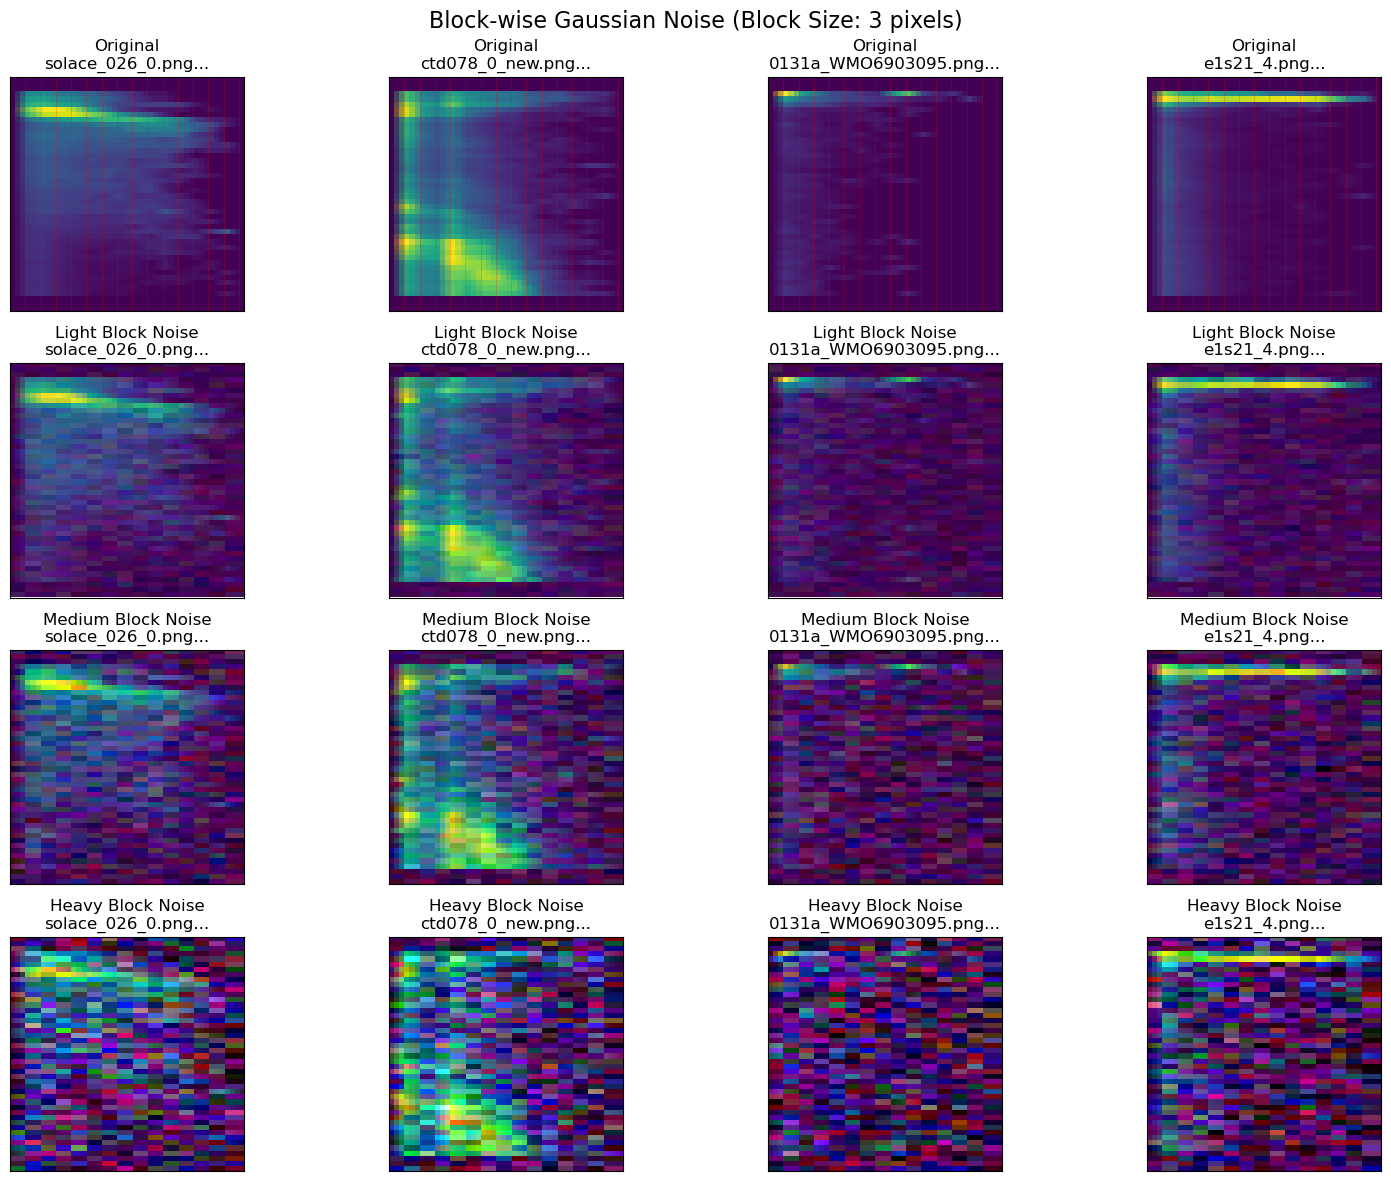


BLOCK-WISE NOISE ANALYSIS
Block size: 3 pixels per datapoint
Number of datapoints along x-axis: 15

Light Block Noise (σ = 0.05):
  Mean absolute difference: 0.0376
  Max absolute difference: 0.1608
  Within-block correlation: 0.996

Medium Block Noise (σ = 0.1):
  Mean absolute difference: 0.0751
  Max absolute difference: 0.3692
  Within-block correlation: 0.997

Heavy Block Noise (σ = 0.2):
  Mean absolute difference: 0.1451
  Max absolute difference: 0.6709
  Within-block correlation: 0.999


In [112]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import tensorflow as tf

def add_block_gaussian_noise(image, noise_level, block_size=3):
    """
    Add Gaussian noise in blocks of pixels along x-axis
    
    Parameters: 
    image (np.array): Input image 
    noise_level (float): Standard deviation of noise
    block_size (int): Number of pixels per block (default 3)
    """
    if noise_level == 0.0:
        return image
    
    height, width = image.shape[: 2]
    n_channels = image.shape[2] if len(image.shape) == 3 else 1
    
    # Calculate number of complete blocks along x-axis
    n_blocks = width // block_size
    effective_width = n_blocks * block_size
    
    # Create noise at the block level (one noise value per block)
    block_noise_shape = (height, n_blocks) + ((n_channels,) if n_channels > 1 else ())
    block_noise = np.random.normal(0, noise_level, block_noise_shape)
    
    # Expand each noise value to fill the entire block (repeat 3 times along x-axis)
    if n_channels > 1:
        # Multi-channel image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        # Handle any remaining pixels if width is not divisible by block_size
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[: , -1: , : ] 
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    else:
        # Grayscale image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[:, -1:]
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    
    # Add noise to image and clip to valid range
    noisy_image = image + pixel_noise
    return np.clip(noisy_image, 0, 1)

def test_block_gaussian_noise(heatmap_dir="../Data/heatmaps", block_size=3):
    """
    Test block-wise Gaussian noise on PNG heatmap files
    """
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Get random heatmap files
    heatmap_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.png')]
    
    if len(heatmap_files) == 0:
        print(f"No .png files found in {heatmap_dir}")
        return
    
    print(f"Found {len(heatmap_files)} PNG heatmap files")
    selected_files = random.sample(heatmap_files, min(4, len(heatmap_files)))
    
    # Load and prepare heatmaps
    heatmaps = []
    for filename in selected_files:
        img_path = os.path.join(heatmap_dir, filename)
        img = Image.open(img_path)
        heatmap = np.array(img).astype(np.float32) / 255.0
        
        # Handle RGBA by removing alpha channel
        if len(heatmap.shape) == 3 and heatmap.shape[2] == 4:
            heatmap = heatmap[: , :, :3]
        
        print(f"Loaded {filename}:  shape {heatmap.shape}")
        print(f"  With block_size={block_size}, this represents {heatmap.shape[1]//block_size} datapoints along x-axis")
        heatmaps.append(heatmap)
    
    # Define noise levels
    noise_configs = [
        (0.0, "Original"),
        (0.05, "Light Block Noise"),  
        (0.1, "Medium Block Noise"),
        (0.2, "Heavy Block Noise")
    ]
    
    # Create plot
    fig, axes = plt.subplots(4, len(selected_files), figsize=(4*len(selected_files), 12))
    
    # Handle single file case
    if len(selected_files) == 1:
        axes = axes.reshape(-1, 1)
    
    for row, (noise_level, label) in enumerate(noise_configs):
        for col in range(len(selected_files)):
            # Apply block-wise noise
            display_data = add_block_gaussian_noise(heatmaps[col], noise_level, block_size)
            
            # Display the heatmap
            if len(display_data.shape) == 3 and display_data.shape[2] == 3:
                # RGB image
                axes[row, col].imshow(display_data)
            elif len(display_data.shape) == 3:
                # Multi-channel - average for display
                axes[row, col].imshow(np.mean(display_data, axis=-1), cmap='viridis')
            else:
                # Grayscale
                axes[row, col].imshow(display_data, cmap='viridis')
            
            axes[row, col].set_title(f"{label}\n{selected_files[col][:20]}...")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
            # Add grid lines to show block structure (optional)
            if row == 0:  # Only on original images
                width = display_data.shape[1]
                for x in range(0, width, block_size):
                    axes[row, col].axvline(x - 0.5, color='red', alpha=0.3, linewidth=0.5)
    
    plt.suptitle(f'Block-wise Gaussian Noise (Block Size: {block_size} pixels)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print noise statistics
    print("\n" + "="*60)
    print("BLOCK-WISE NOISE ANALYSIS")
    print("="*60)
    print(f"Block size: {block_size} pixels per datapoint")
    
    original = heatmaps[0]
    n_datapoints = original.shape[1] // block_size
    print(f"Number of datapoints along x-axis: {n_datapoints}")
    
    for noise_level, label in noise_configs[1:]:
        noisy = add_block_gaussian_noise(original, noise_level, block_size)
        
        mean_diff = np.mean(np.abs(noisy - original))
        max_diff = np.max(np.abs(noisy - original))
        
        # Calculate noise correlation within blocks
        block_correlation = analyze_block_structure(original, noisy, block_size)
        
        print(f"\n{label} (σ = {noise_level}):")
        print(f"  Mean absolute difference: {mean_diff:.4f}")
        print(f"  Max absolute difference: {max_diff:.4f}")
        print(f"  Within-block correlation: {block_correlation:.3f}")

def analyze_block_structure(original, noisy, block_size):
    """Analyze correlation within blocks to verify block structure"""
    height, width = original.shape[:2]
    n_blocks = width // block_size
    
    correlations = []
    noise_diff = noisy - original
    
    for block_idx in range(n_blocks):
        start_x = block_idx * block_size
        end_x = start_x + block_size
        
        if end_x <= width:
            block_noise = noise_diff[:, start_x:end_x]
            
            # Calculate correlation between adjacent pixels in the block
            if block_size > 1:
                pixel1 = block_noise[:, 0].flatten()
                pixel2 = block_noise[:, 1].flatten()
                if len(pixel1) > 0 and len(pixel2) > 0:
                    correlation = np.corrcoef(pixel1, pixel2)[0, 1]
                    if not np.isnan(correlation):
                        correlations.append(correlation)
    
    return np.mean(correlations) if correlations else 0.0

# Test the block-wise noise
test_block_gaussian_noise(heatmap_dir=HEATMAP_DIR, block_size=3)

- noise of 0.05 looks good, the higher levels are too much
- note that noise is added in 3-pixel blocks, same as the datapoint representation

In [113]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BlockGaussianNoise(Layer):
    """Custom layer for block-wise Gaussian noise augmentation"""
    
    def __init__(self, noise_level, block_size=3, seed=None, **kwargs):
        super(BlockGaussianNoise, self).__init__(**kwargs)
        self.noise_level = noise_level
        self.block_size = block_size
        self.seed = seed
        self.supports_masking = True
    
    def build(self, input_shape):
        super(BlockGaussianNoise, self).build(input_shape)
    
    def call(self, inputs, training=None):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def apply_noise():
            # Get input shape
            input_shape = tf.shape(inputs)
            batch_size = input_shape[0]
            height = input_shape[1]
            width = input_shape[2]
            channels = input_shape[3]
            
            # Calculate number of blocks
            n_blocks = width // self.block_size
            effective_width = n_blocks * self.block_size
            
            # Generate noise at block level
            block_noise = tf.random.normal(
                shape=[batch_size, height, n_blocks, channels],
                stddev=self.noise_level,
                seed=self.seed
            )
            
            # Repeat noise for each pixel in the block
            pixel_noise = tf.repeat(block_noise, self.block_size, axis=2)
            
            # Handle remaining pixels if width not divisible by block_size
            if effective_width < width:
                remaining = width - effective_width
                last_block = block_noise[: , :, -1:, :]
                last_expanded = tf.repeat(last_block, remaining, axis=2)
                pixel_noise = tf.concat([pixel_noise, last_expanded], axis=2)
            else:
                # Ensure pixel_noise has the correct width
                pixel_noise = pixel_noise[:, :, :width, :]
            
            # Add noise to inputs
            return inputs + pixel_noise
        
        def no_noise():
            return inputs
        
        return tf.cond(tf.cast(training, tf.bool), apply_noise, no_noise)
    
    def compute_output_shape(self, input_shape):
        return input_shape
    
    def compute_output_spec(self, input_spec):
        return input_spec
    
    def get_config(self):
        config = {
            'noise_level': self.noise_level,
            'block_size': self.block_size,
            'seed': self.seed,
        }
        base_config = super(BlockGaussianNoise, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# Add this to your class
HeatmapCNNClassifier.BlockGaussianNoise = BlockGaussianNoise


### Functions for: CNN model creation, compiling, cross-validation with pre-defined folds

In [114]:
######################## Create CNN model - tune model architecture here ###############################
#######################

# Adjust hyperparameters
learning_rate = 0.001
dropout_rate_conv = 0.25
dropout_rate_dense = 0.5
batch_size = 32
epochs = 100
patience = 10 # patience of early stopping callback
verbose_val = 1 # no output during training
k = 4 # number of folds for cross-validation
metrics_to_monitor = ['accuracy', ]

# augmentation parameters
noise_level = 0.075 # Gaussian noise level - data augmentation
block_size = 3 # Block size for block-wise noise

######################## Create CNN model architecture ###############################

def create_cnn_model(self, input_shape):
    """Create CNN model architecture"""
    print(f"Creating CNN model for input shape: {input_shape}")
    
    model = Sequential([

        # Input layer with block-wise Gaussian noise augmentation
        BlockGaussianNoise(noise_level, block_size, seed=42, input_shape=input_shape),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Fully connected layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate_dense),

        Dense(256, activation='relu'),
        Dropout(dropout_rate_dense),

        Dense(self.n_classes, activation='softmax')         # Output layer for multi-class classification
    ])
    
    return model

# add the function to the class
HeatmapCNNClassifier.create_cnn_model = create_cnn_model


######################## Compile model ###############################

def compile_model(self, model):
    """Compile the CNN model"""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=metrics_to_monitor
    )
    return model

# add the function to the class
HeatmapCNNClassifier.compile_model = compile_model


######################## Fit model once to each fold - cross-validate ###############################
def cross_validate(self):
    """Perform cross-validation using pre-defined folds with balanced data"""
    print("Starting cross-validation with balanced data...")
        
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1':  [],
        'fold_predictions':  [],
        'fold_true_labels': [],
        # Add training metrics tracking
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Store individual fold results for confusion matrices
    self.cv_fold_results = []
    
    for fold in unique_folds:                            ### for-loop over folds
        print(f"\nProcessing fold:  {fold}")
        
        # Get balanced data for this fold
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical: one-hot encoding of clusters for keras
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create and compile model
        model = self.create_cnn_model(X_train_fold.shape[1:])
        model = self.compile_model(model)
        
        # Set up callbacks
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7) # reduce learning rate if no improvement (on plateau)
        
        # Train model
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=verbose_val
        )
        
        # Extract final training metrics from history
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        # Store training metrics
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Make predictions for additional metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate additional validation metrics
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Calculate training metrics on training data
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store individual fold results for confusion matrices
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1':  macro_f1,
            'n_samples': len(y_val_fold),
            # Add training metrics to fold results
            'train_loss':  final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results.append(fold_result)
        
        # Print comprehensive fold results
        print(f"Fold {fold} Results:")
        print(f"  Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_accuracy:.4f}, Bal. Acc: {train_bal_acc:.4f}, F1: {train_macro_f1:.4f}")
        print(f"  Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_accuracy:.4f}, Bal.Acc: {bal_acc:.4f}, F1: {macro_f1:.4f}")
        
    self.cv_results = cv_results
    self.print_cv_results()

# Add the updated function to the class
HeatmapCNNClassifier.cross_validate = cross_validate

######################## Print CV results (integrated in cross_validate) ###############################

def print_cv_results(self):
    """Print comprehensive cross-validation results including training metrics"""
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Validation metrics
    bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results['macro_f1'])
    f1_std = np.std(self.cv_results['macro_f1'])
    val_loss_mean = np.mean(self.cv_results['val_loss'])
    val_loss_std = np.std(self.cv_results['val_loss'])
    val_acc_mean = np.mean(self.cv_results['val_accuracy'])
    val_acc_std = np.std(self.cv_results['val_accuracy'])
    
    # Training metrics
    train_loss_mean = np.mean(self.cv_results['train_loss'])
    train_loss_std = np.std(self.cv_results['train_loss'])
    train_acc_mean = np.mean(self.cv_results['train_accuracy'])
    train_acc_std = np.std(self.cv_results['train_accuracy'])
    
    # Calculate training balanced accuracy and F1 from fold results
    train_bal_accs = [fold['train_balanced_accuracy'] for fold in self.cv_fold_results]
    train_f1s = [fold['train_macro_f1'] for fold in self.cv_fold_results]
    train_bal_acc_mean = np.mean(train_bal_accs)
    train_bal_acc_std = np.std(train_bal_accs)
    train_f1_mean = np.mean(train_f1s)
    train_f1_std = np.std(train_f1s)
    
    print("TRAINING METRICS (average across folds):")
    print(f"  Loss:                 {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Accuracy:            {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {train_bal_acc_mean:.4f} ± {train_bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {train_f1_mean:.4f} ± {train_f1_std:.4f}")
    
    print("\nVALIDATION METRICS (average across folds):")
    print(f"  Loss:                {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Accuracy:            {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    
    # Calculate overfitting indicators
    accuracy_gap = train_acc_mean - val_acc_mean
    loss_gap = val_loss_mean - train_loss_mean  # Higher validation loss indicates overfitting
    bal_acc_gap = train_bal_acc_mean - bal_acc_mean
    
    print("\nOVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (train - val):     {accuracy_gap:.4f}")
    print(f"  Loss Gap (val - train):         {loss_gap:.4f}")
    print(f"  Bal. Accuracy Gap (train - val): {bal_acc_gap:.4f}")
    
    if accuracy_gap > 0.1:
        print("  ⚠️  Large accuracy gap suggests overfitting")
    elif accuracy_gap < 0.02:
        print("  ✅ Good generalization (low accuracy gap)")
    else:
        print("  ➡️  Moderate accuracy gap")
    
    print("\nPER-FOLD BREAKDOWN:")
    print("Fold      | Train Acc | Val Acc | Train F1 | Val F1  | Train Loss | Val Loss")
    print("-"*75)
    for i, fold_result in enumerate(self.cv_fold_results):
        fold_name = fold_result['fold_name']
        train_acc = fold_result['train_accuracy']
        val_acc = fold_result['balanced_accuracy']  # Using balanced accuracy for validation
        train_f1 = fold_result['train_macro_f1']
        val_f1 = fold_result['macro_f1']
        train_loss = fold_result['train_loss']
        val_loss = fold_result['val_loss']
        
        print(f"{fold_name: <9} | {train_acc:.4f}    | {val_acc:.4f}  | {train_f1:.4f}   | {val_f1:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")

# add the function to the class
HeatmapCNNClassifier.print_cv_results = print_cv_results


######################## Confusion Matrix Function ###############################

def plot_cv_fold_confusion_matrices(self, k=k):
    """
    Plot normalized confusion matrices for each CV fold
    
    Parameters:  
    k (int): Number of folds to display (default 4)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import numpy as np
    
    if not hasattr(self, 'cv_results'):
        print("Error: No cross-validation results found.  Run cross_validate() first.")
        return
    
    if not hasattr(self, 'cv_fold_results'):
        print("Error: Individual fold results not available.")
        print("Make sure you're using the updated cross_validate() method.")
        return
    
    n_folds = min(k, len(self.cv_fold_results))
    
    # Set up the subplot grid (2x2 for 4 folds)
    if n_folds <= 2:
        fig, axes = plt.subplots(1, n_folds, figsize=(7*n_folds, 6))
        if n_folds == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
    
    # Color map for consistency
    cmap = 'Blues'
    
    print("\n" + "="*60)
    print("CV FOLD CONFUSION MATRIX SUMMARY")
    print("="*60)
    
    for fold_idx in range(n_folds):
        ax = axes[fold_idx]
        
        # Get predictions and true labels for this fold
        fold_result = self.cv_fold_results[fold_idx]
        y_true_fold = fold_result['y_true']
        y_pred_fold = fold_result['y_pred']
        fold_name = fold_result['fold_name']
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true_fold, y_pred_fold)
        
        # Normalize confusion matrix (row-wise normalization)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Handle any NaN values (in case a class has 0 samples)
        cm_normalized = np.nan_to_num(cm_normalized)
        
        # Create heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.2f', 
                   cmap=cmap,
                   ax=ax,
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   vmin=0, 
                   vmax=1,
                   cbar_kws={'label': 'Normalized Count'})
        
        # Calculate accuracy for this fold
        accuracy = fold_result['balanced_accuracy']
        macro_f1 = fold_result['macro_f1']
        
        ax.set_title(f'{fold_name}\nBal.  Acc: {accuracy:.3f}, F1: {macro_f1:.3f}')
        ax.set_xlabel('Predicted Cluster')
        ax.set_ylabel('True Cluster')
        
        # Print summary for this fold
        print(f"\n{fold_name}:")
        print(f"  Samples: {fold_result['n_samples']}")
        print(f"  Balanced Accuracy: {accuracy:.3f}")
        print(f"  Macro F1: {macro_f1:.3f}")
        
        # Per-class statistics
        print("  Per-class recall (diagonal values):")
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            if class_idx < len(cm_normalized):
                recall = cm_normalized[class_idx, class_idx]
                print(f"    Cluster {class_name}: {recall:.3f}")
    
    # Hide any unused subplots
    if n_folds < len(axes):
        for idx in range(n_folds, len(axes)):
            axes[idx].axis('off')
    
    plt.suptitle('Normalized Confusion Matrices by CV Fold', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Overall summary
    print(f"\n" + "="*60)
    print("OVERALL CV SUMMARY")
    print("="*60)
    all_accuracies = [fold['balanced_accuracy'] for fold in self.cv_fold_results]
    all_f1s = [fold['macro_f1'] for fold in self.cv_fold_results]
    
    print(f"Mean Balanced Accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Mean Macro F1: {np.mean(all_f1s):.3f} ± {np.std(all_f1s):.3f}")

# Add the function to the class
HeatmapCNNClassifier.plot_cv_fold_confusion_matrices = plot_cv_fold_confusion_matrices


### Main function - full pipeline

In [115]:
######################### Full Pipeline Function ###############################
def run_full_pipeline(self):
    """Run the complete pipeline"""
    print("Starting Heatmap CNN Classification Pipeline")
    print("=" * 50)
    
    # Step 1: Load data
    self.load_data_assignments()
    self.load_heatmaps()
    
    # Step 2: Split train/test
    self.split_train_test()
    
    # Step 4: Balance classes per fold
    #self.balance_classes_per_fold_SMOTETomek() # alternative: use SMOTE Tomek Link
    self.balance_classes_per_fold_simple()

    # Step 5: Scale data
    self.scale_data()
    
    # Step 6: Cross-validation
    self.cross_validate()

    # Step 7: Plot CV confusion matrices
    self.plot_cv_fold_confusion_matrices()
            
    print("\nPipeline completed successfully!")

# add the function to the class
HeatmapCNNClassifier.run_full_pipeline = run_full_pipeline


### Run pipeline

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available pro

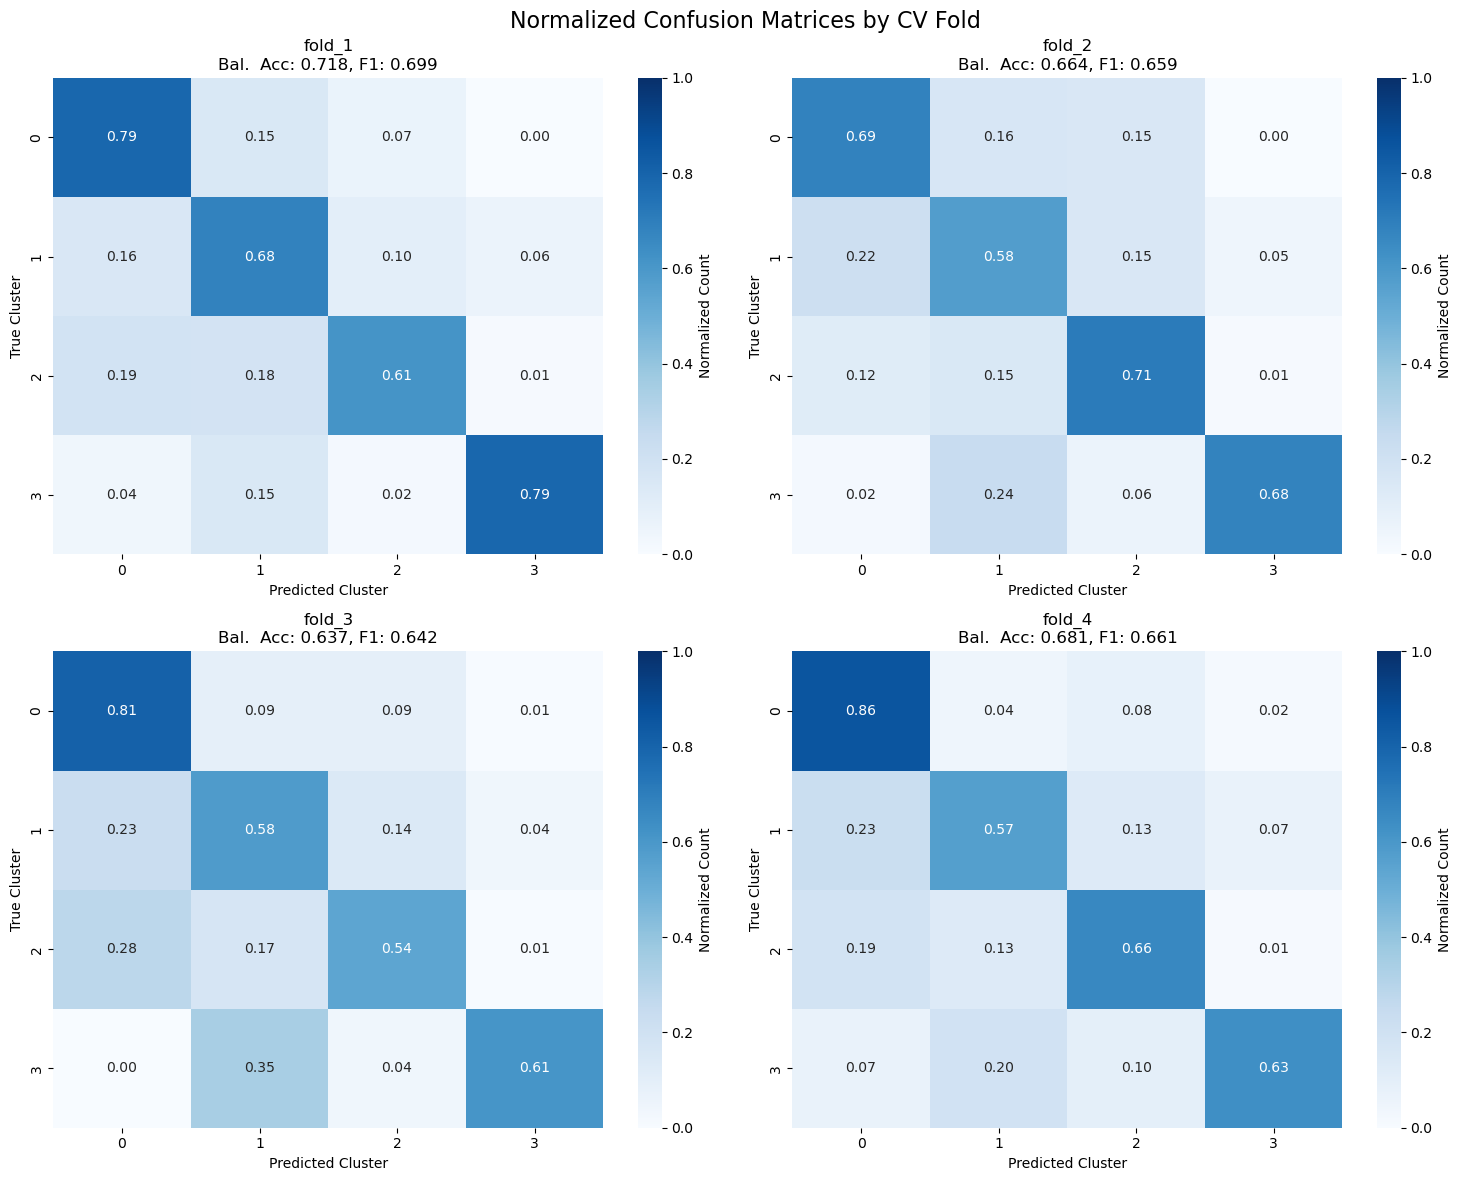


OVERALL CV SUMMARY
Mean Balanced Accuracy: 0.675 ± 0.029
Mean Macro F1: 0.666 ± 0.021

Pipeline completed successfully!


In [116]:
classifier = HeatmapCNNClassifier()
classifier.run_full_pipeline()

# Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


In [ ]:
######################## Initialize classifier and load all data ###############################

print("🚀 Initializing HeatmapCNNClassifier and loading data...")

# Initialize the classifier
classifier = HeatmapCNNClassifier()

# Load data assignments (pickle files)
print("\n📁 Step 1: Loading data assignments...")
classifier.load_data_assignments()

# Load heatmap images
print("\n🖼️ Step 2: Loading heatmap images...")
classifier.load_heatmaps()

# Split into train/test sets
print("\n📊 Step 3: Splitting train/test data...")
classifier.split_train_test()

# Balance classes per fold
print("\n⚖️ Step 4: Balancing classes per fold...")
# Choose one of the balancing methods:
# Option 1: Simple over/undersampling (faster, more predictable)
classifier.balance_classes_per_fold_simple()

# Option 2:  SMOTE-Tomek (more sophisticated but slower)
# classifier.balance_classes_per_fold_SMOTETomek()

# Scale the data
print("\n📏 Step 5: Scaling pixel data...")
classifier.scale_data()

# Verify everything is set up correctly
print("\n✅ Data setup verification:")
print(f"  Training data shape: {classifier.X_train_scaled.shape}")
print(f"  Test data shape: {classifier.X_test_scaled.shape}")
print(f"  Number of classes: {classifier.n_classes}")
print(f"  Class labels: {classifier.label_encoder.classes_}")
print(f"  CV folds available: {list(classifier.fold_balanced_data.keys())}")
print(f"  fold_balanced_data structure: ✅ Ready for optimization")

# Show sample fold data to verify structure
sample_fold = list(classifier.fold_balanced_data.keys())[0]
sample_data = classifier.fold_balanced_data[sample_fold]
print(f"\n📋 Sample fold ({sample_fold}) data:")
print(f"  X_train_scaled shape: {sample_data['X_train_scaled'].shape}")
print(f"  y_train shape: {sample_data['y_train'].shape}")
print(f"  X_val_scaled shape: {sample_data['X_val_scaled'].shape}")
print(f"  y_val shape: {sample_data['y_val'].shape}")

print("\n🎯 Classifier is now ready for hyperparameter optimization!")
print("You can now run:")
print("  best_config, results = classifier.optimize_hyperparameters_smart()")

🚀 Initializing HeatmapCNNClassifier and loading data...

📁 Step 1: Loading data assignments...
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}

🖼️ Step 2: Loading heatmap images...
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO59

### Functions for Ray Tune optuna tuning

In [ ]:
######################## Enhanced Optuna Optimization with 3-Fold Training + 1-Fold Validation ###############################

import optuna
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from sklearn.metrics import balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
import math
import pickle
import uuid
import gc

######################## Optimized CNN model creation for Optuna ###############################

def create_optuna_cnn_model(self, input_shape, config):
    """Create CNN model with Optuna-optimized hyperparameters"""
    
    print(f"Creating Optuna CNN model with input shape: {input_shape}")
    
    model = Sequential([
        # Input layer with optimized noise augmentation
        BlockGaussianNoise(config["noise_level"], config["block_size"], seed=42, input_shape=input_shape),

        # First convolutional block with optimized filters
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Second convolutional block with optimized filters
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Third convolutional block with optimized filters
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Fully connected layers with optimized sizes
        Flatten(),
        Dense(config["dense_units_1"], activation='relu'),
        BatchNormalization(),
        Dropout(config["dropout_rate_dense"]),

        Dense(config["dense_units_2"], activation='relu'),
        Dropout(config["dropout_rate_dense"]),

        Dense(self.n_classes, activation='softmax')
    ])
    
    return model

# Add to class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model

######################## Multi-Fold Data Preparation Function ###############################

######################## Corrected Multi-Fold Data Preparation - Direct Fold Access ###############################

def prepare_multi_fold_data(self, validation_fold=None):
    """
    Prepare training and validation data for the specified CV fold
    Uses the pre-balanced training data for the selected fold
    
    Parameters:  
    -----------
    validation_fold : str or None
        Which fold to use for validation (e.g., 'fold_1'). If None, uses 'fold_1'
    
    Returns:
    --------
    dict:  Dictionary containing training and validation data for the specified fold
    """
    
    if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
        raise ValueError("No fold_balanced_data found.  Run the full pipeline first.")
    
    available_folds = list(self.fold_balanced_data.keys())
    print(f"Available folds: {available_folds}")
    
    # Select validation fold
    if validation_fold is None:  
        validation_fold = available_folds[0]  # Default to first fold
    
    if validation_fold not in available_folds:
        raise ValueError(f"Validation fold {validation_fold} not found.  Available: {available_folds}")
    
    print(f"📊 Multi-fold data preparation:")
    print(f"  Selected CV fold: {validation_fold}")
    
    # Get the pre-balanced data for this specific fold
    fold_data = self.fold_balanced_data[validation_fold]
    
    # Extract training data (already balanced for this CV setup)
    X_train_final = fold_data['X_train_scaled']  # Balanced training data
    y_train_final = fold_data['y_train']         # Balanced training labels
    
    # Extract validation data (original, unbalanced)
    X_val_final = fold_data['X_val_scaled']      # Original validation data
    y_val_final = fold_data['y_val']             # Original validation labels
    
    print(f"  📈 DATA SUMMARY FOR {validation_fold}:")
    print(f"    Training data:  {X_train_final.shape} (balanced)")
    print(f"    Validation data: {X_val_final.shape} (original, unbalanced)")
    print(f"    Train/Val ratio:  {X_train_final.shape[0]/(X_train_final.shape[0] + X_val_final.shape[0]):.1%} / {X_val_final.shape[0]/(X_train_final.shape[0] + X_val_final.shape[0]):.1%}")
    
    # Show class distribution in training data
    from collections import Counter
    train_class_dist = Counter(y_train_final)
    print(f"    Training class distribution (balanced):")
    for class_idx in sorted(train_class_dist.keys()):
        class_name = self.label_encoder.classes_[class_idx] if hasattr(self, 'label_encoder') else str(class_idx)
        count = train_class_dist[class_idx]
        print(f"      Class {class_name}: {count} samples")
    
    # Show class distribution in validation data
    val_class_dist = Counter(y_val_final)
    print(f"    Validation class distribution (original, unbalanced):")
    for class_idx in sorted(val_class_dist.keys()):
        class_name = self.label_encoder.classes_[class_idx] if hasattr(self, 'label_encoder') else str(class_idx)
        count = val_class_dist[class_idx]
        print(f"      Class {class_name}: {count} samples")
    
    # Determine which folds were used for training (for informational purposes)
    all_folds = set(available_folds)
    training_folds = list(all_folds - {validation_fold})
    
    return {
        'X_train':  X_train_final,
        'y_train': y_train_final,
        'X_val': X_val_final,
        'y_val': y_val_final,
        'training_folds': training_folds,  # For information only
        'validation_fold': validation_fold
    }

# Replace the function
HeatmapCNNClassifier.prepare_multi_fold_data = prepare_multi_fold_data


######################## Enhanced Optuna Optimization with Multi-Fold Training ###############################

def optimize_cnn_with_optuna_multi_fold(self, num_trials=30, max_epochs=50, validation_fold=None, 
                                       timeout_minutes=60, overfitting_penalty_weight=2.0,
                                       save_directory='../Data/', auto_save=True, auto_plot=True):
    """
    Enhanced Anti-Overfitting Optuna CNN optimization using 3 folds for training and 1 fold for validation
    
    Parameters:
    -----------
    num_trials : int
        Number of trials to run
    max_epochs : int
        Maximum epochs per trial
    validation_fold : str or None
        Which fold to use for validation (e.g., 'fold_1'). Others used for training
    timeout_minutes :  int
        Maximum time to run optimization (in minutes)
    overfitting_penalty_weight : float
        Weight for overfitting penalty (higher = more anti-overfitting focus)
    save_directory : str
        Directory to save the best configuration
    auto_save : bool
        Whether to automatically save best parameters
    auto_plot : bool
        Whether to automatically create and display plots
    """
    
    print("🎯 Starting Multi-Fold Anti-Overfitting Optuna CNN Optimization...")
    print(f"  Trials: {num_trials}")
    print(f"  Max epochs per trial: {max_epochs}")
    print(f"  Timeout:  {timeout_minutes} minutes")
    print(f"  Overfitting penalty weight: {overfitting_penalty_weight}")
    print("  📊 Strategy:  3 folds for training + 1 fold for validation")
    print("  🎯 PRIORITY: Overfitting reduction > Raw validation accuracy")
    
    # Prepare multi-fold data
    try:
        multi_fold_data = self.prepare_multi_fold_data(validation_fold)
    except Exception as e:
        print(f"❌ Error preparing multi-fold data: {e}")
        return None, None
    
    X_train = multi_fold_data['X_train']
    y_train = multi_fold_data['y_train']
    X_val = multi_fold_data['X_val']
    y_val = multi_fold_data['y_val']
    training_folds = multi_fold_data['training_folds']
    validation_fold = multi_fold_data['validation_fold']
    
    print(f"✅ Using {len(training_folds)} folds for training, {validation_fold} for validation")
    print(f"Number of classes: {self.n_classes}")
    
    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, self.n_classes)
    y_val_cat = to_categorical(y_val, self.n_classes)
    
    # Define comprehensive objective function with history storage
    def multi_fold_objective(trial):
        """Multi-fold anti-overfitting objective function with full tracking"""
        
        trial_num = trial.number + 1
        print(f"\n🔬 Trial {trial_num}/{num_trials}")
        
        # Suggest hyperparameters with enhanced dropout ranges for better regularization
        config = {
            # ADJUSTED:  Narrow to sweet spot, extend upper bound slightly
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),  #
            
            # KEEP:  128 batch size performed well
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),  
            
            # FINE-TUNE: Lower bounds slightly, keep upper bounds
            "dropout_rate_conv":  trial.suggest_float("dropout_rate_conv", 0.15, 0.6),   #
            "dropout_rate_dense": trial.suggest_float("dropout_rate_dense", 0.4, 0.8), # 
            
            # EXPAND: Increase upper bounds for better architectures
            "conv_filters_1": trial.suggest_categorical("conv_filters_1", [16, 24, 32, 48]),     
            "conv_filters_2": trial.suggest_categorical("conv_filters_2", [32, 48, 64, 96]),    
            "conv_filters_3": trial.suggest_categorical("conv_filters_3", [64, 96, 128, 192]),  
            
            # EXPAND: Increase capacity for better performance
            "dense_units_1": trial.suggest_categorical("dense_units_1", [256, 384, 512, 768]), 
            "dense_units_2": trial. suggest_categorical("dense_units_2", [128, 192, 256, 384]),  
            
            # KEEP: These ranges worked well
            "noise_level": trial.suggest_float("noise_level", 0.01, 0.2),              #
            "block_size": trial. suggest_categorical("block_size", [2, 3, 4]),
            
            # FINE-TUNE:  Focus on working range
            "lr_reduction_factor": trial.suggest_float("lr_reduction_factor", 0.2, 0.6), 
            "lr_patience": trial.suggest_categorical("lr_patience", [3, 4, 5,6]),           # Removed 6
            "early_stop_patience": trial.suggest_categorical("early_stop_patience", [10, 12, 15, 18]), # Removed 10
        }
        
        print(f"  LR:  {config['learning_rate']:.6f}")
        print(f"  Batch size: {config['batch_size']}")
        print(f"  Conv filters: [{config['conv_filters_1']}, {config['conv_filters_2']}, {config['conv_filters_3']}]")
        print(f"  Dense units: [{config['dense_units_1']}, {config['dense_units_2']}]")
        print(f"  Dropout:  Conv={config['dropout_rate_conv']:.3f}, Dense={config['dropout_rate_dense']:.3f}")
        
        try:
            # Create and compile model
            model = self.create_optuna_cnn_model(X_train.shape[1:], config)
            
            optimizer = Adam(learning_rate=config["learning_rate"])
            model.compile(
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Setup callbacks
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=config["early_stop_patience"],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=config["lr_reduction_factor"],
                    patience=config["lr_patience"],
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train model
            print(f"  Training for up to {max_epochs} epochs...")
            print(f"    Training on:  {[f for f in training_folds]} ({X_train.shape[0]} samples)")
            print(f"    Validating on: {validation_fold} ({X_val.shape[0]} samples)")
            
            history = model.fit(
                X_train, y_train_cat,
                validation_data=(X_val, y_val_cat),
                epochs=max_epochs,
                batch_size=config["batch_size"],
                callbacks=callbacks,
                verbose=0
            )
            
            # Calculate metrics
            if len(history.history['val_loss']) == 0:
                print(f"  ❌ No training history available")
                trial.set_user_attr('history', {})
                trial.set_user_attr('config', config)
                trial.set_user_attr('data_split', {
                    'training_folds': training_folds,
                    'validation_fold': validation_fold
                })
                trial.set_user_attr('status', 'failed_no_history')
                return 0.0
            
            # Get predictions on both training and validation sets
            y_train_pred_proba = model.predict(X_train, verbose=0)
            y_train_pred = np.argmax(y_train_pred_proba, axis=1)
            
            y_val_pred_proba = model.predict(X_val, verbose=0)
            y_val_pred = np.argmax(y_val_pred_proba, axis=1)
            
            # Calculate comprehensive performance metrics
            train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)
            val_balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
            
            train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')
            val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
            
            # Get loss metrics
            final_train_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            best_val_loss = min(history.history['val_loss'])
            epochs_trained = len(history.history['loss'])
            
            # Calculate comprehensive overfitting metrics
            accuracy_gap = train_balanced_acc - val_balanced_acc
            loss_gap = final_val_loss - final_train_loss
            f1_gap = train_macro_f1 - val_macro_f1
            
            # Composite overfitting score (higher = more overfitted)
            overfitting_score = (accuracy_gap * 2 + loss_gap + f1_gap) / 4
            
            # Anti-overfitting objective:  Validation accuracy minus overfitting penalty
            objective_score = val_balanced_acc - (overfitting_penalty_weight * max(0, overfitting_score))
            
            print(f"  ✅ Val Acc: {val_balanced_acc:.4f}, Train Acc: {train_balanced_acc:.4f}")
            print(f"     Accuracy Gap: {accuracy_gap:.4f}, Overfitting Score: {overfitting_score:.4f}")
            print(f"     🎯 Objective Score: {objective_score:.4f} (higher is better)")
            
            # Store comprehensive results INCLUDING LEARNING HISTORY
            trial.set_user_attr('history', {
                'loss': history.history['loss'],
                'val_loss': history.history['val_loss'],
                'accuracy':  history.history['accuracy'],
                'val_accuracy': history.history['val_accuracy']
            })
            trial.set_user_attr('config', config)
            trial.set_user_attr('data_split', {
                'training_folds': training_folds,
                'validation_fold': validation_fold,
                'train_samples': X_train.shape[0],
                'val_samples':  X_val.shape[0]
            })
            trial.set_user_attr('val_balanced_acc', val_balanced_acc)
            trial.set_user_attr('train_balanced_acc', train_balanced_acc)
            trial.set_user_attr('val_macro_f1', val_macro_f1)
            trial.set_user_attr('train_macro_f1', train_macro_f1)
            trial.set_user_attr('val_loss', best_val_loss)
            trial.set_user_attr('final_val_loss', final_val_loss)
            trial.set_user_attr('final_train_loss', final_train_loss)
            trial.set_user_attr('epochs_trained', epochs_trained)
            trial.set_user_attr('accuracy_gap', accuracy_gap)
            trial.set_user_attr('loss_gap', loss_gap)
            trial.set_user_attr('f1_gap', f1_gap)
            trial.set_user_attr('overfitting_score', overfitting_score)
            trial.set_user_attr('status', 'success')
            
            # Cleanup
            del model
            gc.collect()
            
            return objective_score
            
        except Exception as e:
            print(f"  ❌ Trial failed: {str(e)}")
            # Store config and failure status even for failed trials
            trial.set_user_attr('history', {})
            trial.set_user_attr('config', config)
            trial.set_user_attr('data_split', {
                'training_folds':  training_folds,
                'validation_fold': validation_fold
            })
            trial.set_user_attr('status', f'failed_{str(e)[: 20]}')
            try:
                del model
                gc.collect()
            except:
                pass
            return 0.0
    
    # Create and configure Optuna study
    study_name = f'multi_fold_cnn_optimization_{uuid.uuid4().hex[:8]}'
    
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=8,
        n_warmup_steps=8,
        interval_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=None,
        pruner=pruner
    )
    
    print(f"\n🚀 Starting multi-fold optimization study: {study_name}")
    
    # Run optimization
    try:
        study.optimize(
            multi_fold_objective,
            n_trials=num_trials,
            timeout=timeout_minutes * 60,
            show_progress_bar=True,
            gc_after_trial=True
        )
        
    except KeyboardInterrupt:
        print("\n⚠️ Optimization interrupted by user")
    except Exception as e:
        print(f"\n❌ Optimization failed: {e}")
        return None, None
    
    # Enhanced results analysis
    print(f"\n📊 MULTI-FOLD OPTIMIZATION COMPLETED")
    print(f"  Training folds used: {training_folds}")
    print(f"  Validation fold used: {validation_fold}")
    print(f"  Completed trials: {len(study.trials)}")
    print(f"  Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
    print(f"  Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    if study.best_trial is None:
        print("❌ No successful trials found")
        return None, None
    
    # Get best results
    best_trial = study.best_trial
    best_params = best_trial.params
    best_score = best_trial.value
    
    print(f"\n🏆 BEST MULTI-FOLD ANTI-OVERFITTING CONFIGURATION:")
    print(f"  🎯 Anti-Overfitting Objective Score: {best_score:.4f}")
    
    if 'val_balanced_acc' in best_trial.user_attrs:
        attrs = best_trial.user_attrs
        data_split = attrs.get('data_split', {})
        print(f"  📊 Data Split: {data_split.get('train_samples', 'N/A')} train / {data_split.get('val_samples', 'N/A')} val")
        print(f"  Validation Balanced Accuracy: {attrs['val_balanced_acc']:.4f}")
        print(f"  Training Balanced Accuracy: {attrs['train_balanced_acc']:.4f}")
        print(f"  Accuracy Gap (train - val): {attrs['accuracy_gap']:.4f}")
        print(f"  Loss Gap (val - train): {attrs['loss_gap']:.4f}")
        print(f"  Composite Overfitting Score: {attrs['overfitting_score']:.4f}")
        print(f"  Epochs Trained: {attrs['epochs_trained']}")
        
        # Overfitting assessment
        if attrs['accuracy_gap'] < 0.05:
            print(f"  🎯 EXCELLENT: Minimal overfitting detected!")
        elif attrs['accuracy_gap'] < 0.10:
            print(f"  ✅ GOOD: Low overfitting")
        elif attrs['accuracy_gap'] < 0.15:
            print(f"  ⚠️ MODERATE: Some overfitting present")
        else:
            print(f"  🚨 HIGH: Significant overfitting detected")
    
    # Store results in classifier
    self.optuna_study = study
    self.best_optuna_params = best_params
    self.best_optuna_config = best_params
    self.overfitting_penalty_weight = overfitting_penalty_weight
    self.optimization_data_split = {
        'training_folds':  training_folds,
        'validation_fold': validation_fold
    }
    
    # AUTOMATIC PARAMETER SAVING
    if auto_save: 
        try:
            import os
            os.makedirs(save_directory, exist_ok=True)
            
            save_path = save_directory + 'optimal_config_optuna_multi_fold.pkl'
            with open(save_path, 'wb') as f:
                pickle.dump(best_params, f)
            print(f"\n💾 BEST CONFIGURATION AUTOMATICALLY SAVED:")
            print(f"   📁 File: {save_path}")
            print(f"   ✅ Parameters saved successfully")
            
            # Also save comprehensive optimization results
            comprehensive_results = {
                'best_params': best_params,
                'best_score': best_score,
                'best_trial_attrs': best_trial.user_attrs,
                'optimization_settings': {
                    'num_trials': num_trials,
                    'max_epochs': max_epochs,
                    'overfitting_penalty_weight': overfitting_penalty_weight,
                    'training_folds': training_folds,
                    'validation_fold': validation_fold
                },
                'study_stats': {
                    'total_trials': len(study.trials),
                    'successful_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
                    'pruned_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]),
                    'failed_trials':  len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])
                }
            }
            
            comprehensive_path = save_directory + 'optuna_multi_fold_results_complete.pkl'
            with open(comprehensive_path, 'wb') as f:
                pickle.dump(comprehensive_results, f)
            print(f"   📁 Comprehensive results:  {comprehensive_path}")
            
        except Exception as e:
            print(f"\n❌ Error saving parameters: {e}")
    
    # AUTOMATIC PLOTTING
    if auto_plot: 
        print(f"\n📊 Creating automatic multi-fold visualization...")
        try:
            self.plot_multi_fold_results(top_n=6, save_path=save_directory + 'optuna_multi_fold_results.png' if auto_save else None)
        except Exception as e:
            print(f"❌ Error creating plots: {e}")
    
    print(f"\n✅ Multi-fold optimization complete!")
    print(f"📊 Learning histories stored for {len(study.trials)} trials")
    
    return best_params, study

# Add to class
HeatmapCNNClassifier.optimize_cnn_with_optuna_multi_fold = optimize_cnn_with_optuna_multi_fold

######################## Enhanced Visualization for Multi-Fold Results ###############################

def plot_multi_fold_results(self, top_n=6, figsize=(16, 14), save_path=None):
    """
    Create visualization specifically for multi-fold optimization results
    """
    
    if not hasattr(self, 'optuna_study'):
        print("❌ No Optuna study found.  Run optimization first.")
        return
    
    study = self.optuna_study
    
    # Filter successful trials with history
    trials_with_history = []
    for trial in study.trials:
        if ('history' in trial.user_attrs and 
            trial.user_attrs['history'] and 
            'loss' in trial.user_attrs['history']):
            trials_with_history.append(trial)
    
    if not trials_with_history:
        print("❌ No trials with learning history found.")
        return
    
    # Sort by objective score and take top N
    trials_with_history. sort(key=lambda t: t.value or 0, reverse=True)
    top_trials = trials_with_history[:top_n]
    
    n_trials = len(top_trials)
    print(f"📊 Creating multi-fold visualization for top {n_trials} trials")
    
    # Create figure with optimal layout
    fig = plt.figure(figsize=figsize)
    
    # Calculate grid:  3 columns max for clean layout
    n_cols = min(3, n_trials)
    n_rows = math.ceil(n_trials / n_cols)
    
    # Calculate global scales for consistency
    all_losses, all_val_losses, all_accuracies, all_val_accuracies = [], [], [], []
    
    for trial in top_trials:
        history = trial.user_attrs['history']
        all_losses.extend(history['loss'])
        all_val_losses.extend(history['val_loss'])
        all_accuracies.extend(history['accuracy'])
        all_val_accuracies.extend(history['val_accuracy'])
    
    max_loss = max(max(all_losses), max(all_val_losses)) * 1.1
    max_acc = min(1.0, max(max(all_accuracies), max(all_val_accuracies)) * 1.05)
    
    # Create subplots with proper spacing
    gs = fig.add_gridspec(n_rows, n_cols, 
                         height_ratios=[1] * n_rows,
                         hspace=0.4, wspace=0.3,
                         top=0.82, bottom=0.25)
    
    for idx, trial in enumerate(top_trials):
        row = idx // n_cols
        col = idx % n_cols
        
        ax = fig.add_subplot(gs[row, col])
        
        # Get data
        history = trial.user_attrs['history']
        config = trial.user_attrs['config']
        data_split = trial.user_attrs.get('data_split', {})
        
        epochs = range(1, len(history['loss']) + 1)
        
        # Plot loss curves
        ax.plot(epochs, history['loss'], 'b-', label='Train Loss', linewidth=2.5)
        ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2.5)
        
        # Create secondary axis for accuracy
        ax2 = ax.twinx()
        ax2.plot(epochs, history['accuracy'], 'b--', label='Train Acc', linewidth=2.5, alpha=0.8)
        ax2.plot(epochs, history['val_accuracy'], 'r--', label='Val Acc', linewidth=2.5, alpha=0.8)
        
        # Set consistent limits starting from 0
        ax.set_ylim(0, max_loss)
        ax2.set_ylim(0, max_acc)
        
        # Styling
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12, color='black')
        ax2.set_ylabel('Accuracy', fontsize=12, color='black')
        ax.grid(True, alpha=0.3)
        
        # Title with key metrics and data split info
        objective_score = trial.value or 0
        val_acc = trial.user_attrs.get('val_balanced_acc', 0)
        acc_gap = trial.user_attrs.get('accuracy_gap', 0)
        epochs_trained = trial.user_attrs.get('epochs_trained', 0)
        
        # Get data split info
        train_samples = data_split.get('train_samples', 'N/A')
        val_samples = data_split.get('val_samples', 'N/A')
        
        title = (f"Rank #{idx+1}:  Trial {trial.number}\n"
                f"Obj:  {objective_score:.4f} | Val Acc: {val_acc:.4f} | Gap: {acc_gap:.4f}\n"
                f"Train:  {train_samples} samples | Val: {val_samples} samples")
        ax.set_title(title, fontsize=10, pad=10, fontweight='bold')
        
        # LEGENDS:  Place clearly outside plot area
        if idx == 0:  # Only show legend for first plot to avoid repetition
            # Combine all lines for single legend
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            
            # Place legend outside figure area
            fig.legend(lines1 + lines2, labels1 + labels2, 
                      loc='upper center', bbox_to_anchor=(0.5, 0.9),
                      ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=12)
    
    # Get data split information for title
    if hasattr(self, 'optimization_data_split'):
        data_split_info = self.optimization_data_split
        training_folds = data_split_info.get('training_folds', [])
        validation_fold = data_split_info.get('validation_fold', 'N/A')
    else:
        # Fallback to first trial's data split info
        first_trial = top_trials[0]
        data_split = first_trial.user_attrs.get('data_split', {})
        training_folds = data_split.get('training_folds', [])
        validation_fold = data_split.get('validation_fold', 'N/A')
    
    # MAIN TITLE with multi-fold information
    best_score = top_trials[0].value or 0
    penalty_weight = getattr(self, 'overfitting_penalty_weight', 2.0)
    
    main_title = (f'Multi-Fold Optuna CNN Optimization Results - Anti-Overfitting Focus\n'
                 f'Training Folds: {training_folds} | Validation Fold: {validation_fold}\n'
                 f'Best Objective Score: {best_score:.4f} | Penalty Weight: {penalty_weight} | Top {n_trials} Trials')
    
    fig.suptitle(main_title, fontsize=14, fontweight='bold', y=0.95)
    
    # CONFIGURATION TABLE:  Create comprehensive config display below plots
    config_y_start = 0.02
    config_height = 0.20
    
    # Create text area for configuration details
    config_ax = fig.add_axes([0.05, config_y_start, 0.9, config_height])
    config_ax.axis('off')
    
    # Prepare configuration table
    config_text_lines = []
    config_text_lines.append("🏆 DETAILED CONFIGURATION FOR TOP MULTI-FOLD TRIALS:")
    config_text_lines.append("=" * 140)
    
    # Header
    header = f"{'Rank': >4} | {'Trial':>5} | {'LR':>8} | {'Batch': >5} | {'Conv Drop':>9} | {'Dense Drop':>10} | {'Conv Filters':>15} | {'Dense Units':>12} | {'Noise': >5} | {'Early Stop':>10} | {'Train/Val': >10}"
    config_text_lines.append(header)
    config_text_lines.append("-" * 140)
    
    # Configuration details for each trial
    for idx, trial in enumerate(top_trials):
        config = trial.user_attrs['config']
        data_split = trial.user_attrs.get('data_split', {})
        train_samples = data_split.get('train_samples', 'N/A')
        val_samples = data_split.get('val_samples', 'N/A')
        
        line = (f"{idx+1:>4} | "
               f"{trial.number:>5} | "
               f"{config['learning_rate']:>8.2e} | "
               f"{config['batch_size']:>5} | "
               f"{config['dropout_rate_conv']:>9.3f} | "
               f"{config['dropout_rate_dense']: >10.3f} | "
               f"{config['conv_filters_1']}-{config['conv_filters_2']}-{config['conv_filters_3']: >6} | "
               f"{config['dense_units_1']}-{config['dense_units_2']: >6} | "
               f"{config['noise_level']:>5.3f} | "
               f"{config['early_stop_patience']:>10} | "
               f"{train_samples}/{val_samples:>4}")
        
        config_text_lines.append(line)
    
    # Display configuration table
    full_config_text = '\n'.join(config_text_lines)
    config_ax.text(0.5, 0.5, full_config_text,
                  transform=config_ax.transAxes,
                  fontsize=8, ha='center', va='center',
                  fontfamily='monospace',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    # Scale information
    #fig.text(0.5, 0.84, f'Consistent Scales:  Loss [0, {max_loss:.2f}] | Accuracy [0, {max_acc:.2f}]',
    #         ha='center', fontsize=11, style='italic', color='blue')
    
    # Save or show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"📁 Multi-fold plot saved to:  {save_path}")
    else:
        plt.show()
    
    return fig

# Add to class
HeatmapCNNClassifier.plot_multi_fold_results = plot_multi_fold_results

######################## Usage Examples ###############################

print("✅ Enhanced Multi-Fold Optuna CNN Optimization Loaded!")
print("\n🎯 MULTI-FOLD FEATURES:")
print("  • Uses 3 folds for training + 1 fold for validation")
print("  • Much more robust than single fold optimization")
print("  • Anti-overfitting objective with comprehensive tracking")
print("  • Automatic parameter saving with multi-fold info")
print("  • Enhanced visualization showing data split details")

print("\n📊 DATA USAGE:")
print("  • Training:  3 complete folds combined (~75% of total data)")
print("  • Validation: 1 complete fold (~25% of total data)")
print("  • Much larger training set for better learning")
print("  • Cleaner validation (no internal train/val split)")

print("\n🚀 USAGE:")
print("# Run multi-fold optimization:")
print("best_params, study = classifier.optimize_cnn_with_optuna_multi_fold(")
print("    num_trials=30,")
print("    max_epochs=30,")
print("    validation_fold='fold_1',  # Use fold_1 for validation, others for training")
print("    overfitting_penalty_weight=2.0)")
print("")
print("# Try different validation folds:")
print("results = {}")
print("for val_fold in ['fold_1', 'fold_2', 'fold_3', 'fold_4']:")
print("    best_params, study = classifier.optimize_cnn_with_optuna_multi_fold(validation_fold=val_fold)")
print("    results[val_fold] = best_params")

# Example usage: 
# best_params, study = classifier.optimize_cnn_with_optuna_multi_fold(
#     num_trials=20,
#     max_epochs=25,
#     validation_fold='fold_1',
#     overfitting_penalty_weight=2.0,
#     auto_save=True,
#     auto_plot=True
# )

✅ Enhanced Multi-Fold Optuna CNN Optimization Loaded!

🎯 MULTI-FOLD FEATURES:
  • Uses 3 folds for training + 1 fold for validation
  • Much more robust than single fold optimization
  • Anti-overfitting objective with comprehensive tracking
  • Automatic parameter saving with multi-fold info
  • Enhanced visualization showing data split details

📊 DATA USAGE:
  • Training:  3 complete folds combined (~75% of total data)
  • Validation: 1 complete fold (~25% of total data)
  • Much larger training set for better learning
  • Cleaner validation (no internal train/val split)

🚀 USAGE:
# Run multi-fold optimization:
best_params, study = classifier.optimize_cnn_with_optuna_multi_fold(
    num_trials=30,
    max_epochs=30,
    validation_fold='fold_1',  # Use fold_1 for validation, others for training
    overfitting_penalty_weight=2.0)

# Try different validation folds:
results = {}
for val_fold in ['fold_1', 'fold_2', 'fold_3', 'fold_4']:
    best_params, study = classifier.optimize_cnn_w

## Tuning

[I 2026-01-16 14:34:32,329] A new study created in memory with name: multi_fold_cnn_optimization_eaca4602


🎯 Starting Multi-Fold Anti-Overfitting Optuna CNN Optimization...
  Trials: 30
  Max epochs per trial: 40
  Timeout:  60 minutes
  Overfitting penalty weight: 1.1
  📊 Strategy:  3 folds for training + 1 fold for validation
  🎯 PRIORITY: Overfitting reduction > Raw validation accuracy
Available folds: [np.str_('fold_1'), np.str_('fold_2'), np.str_('fold_3'), np.str_('fold_4')]
📊 Multi-fold data preparation:
  Selected CV fold: fold_1
  📈 DATA SUMMARY FOR fold_1:
    Training data:  (3148, 46, 46, 3) (balanced)
    Validation data: (1063, 46, 46, 3) (original, unbalanced)
    Train/Val ratio:  74.8% / 25.2%
    Training class distribution (balanced):
      Class 0: 787 samples
      Class 1: 787 samples
      Class 2: 787 samples
      Class 3: 787 samples
    Validation class distribution (original, unbalanced):
      Class 0: 397 samples
      Class 1: 282 samples
      Class 2: 337 samples
      Class 3: 47 samples
✅ Using 3 folds for training, fold_1 for validation
Number of classes:

  0%|          | 0/30 [00:00<?, ?it/s]


🔬 Trial 1/30
  LR:  0.000292
  Batch size: 64
  Conv filters: [16, 48, 128]
  Dense units: [256, 384]
  Dropout:  Conv=0.203, Dense=0.429
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 40 epochs...
    Training on:  [np.str_('fold_2'), np.str_('fold_4'), np.str_('fold_3')] (3148 samples)
    Validating on: fold_1 (1063 samples)


Best trial: 0. Best value: 0.443736:   3%|▎         | 1/30 [01:28<42:50, 88.62s/it, 88.62/3600 seconds]

...


🔬 Trial 21/30
  LR:  0.000135
  Batch size: 16
  Conv filters: [32, 96, 96]
  Dense units: [384, 384]
  Dropout:  Conv=0.422, Dense=0.526
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 40 epochs...
    Training on:  [np.str_('fold_2'), np.str_('fold_4'), np.str_('fold_3')] (3148 samples)
    Validating on: fold_1 (1063 samples)


Best trial: 17. Best value: 0.605106:  67%|██████▋   | 20/30 [1:02:42<30:09, 180.93s/it, 3443.59/3600 seconds]

  ✅ Val Acc: 0.6504, Train Acc: 0.7179
     Accuracy Gap: 0.0675, Overfitting Score: 0.0790
     🎯 Objective Score: 0.5635 (higher is better)
[I 2026-01-16 15:37:15,321] Trial 20 finished with value: 0.5635071717468683 and parameters: {'learning_rate': 0.00013495081472090302, 'batch_size': 16, 'dropout_rate_conv': 0.4222536509168593, 'dropout_rate_dense': 0.526088821253838, 'conv_filters_1': 32, 'conv_filters_2': 96, 'conv_filters_3': 96, 'dense_units_1': 384, 'dense_units_2': 384, 'noise_level': 0.057545485872212934, 'block_size': 3, 'lr_reduction_factor': 0.28001970235233953, 'lr_patience': 6, 'early_stop_patience': 15}. Best is trial 17 with value: 0.6051059112454505.


Best trial: 17. Best value: 0.605106:  70%|███████   | 21/30 [1:02:43<26:52, 179.22s/it, 3763.61/3600 seconds]



📊 MULTI-FOLD OPTIMIZATION COMPLETED
  Training folds used: [np.str_('fold_2'), np.str_('fold_4'), np.str_('fold_3')]
  Validation fold used: fold_1
  Completed trials: 21
  Pruned trials: 0
  Failed trials: 0

🏆 BEST MULTI-FOLD ANTI-OVERFITTING CONFIGURATION:
  🎯 Anti-Overfitting Objective Score: 0.6051
  📊 Data Split: 3148 train / 1063 val
  Validation Balanced Accuracy: 0.7024
  Training Balanced Accuracy: 0.7865
  Accuracy Gap (train - val): 0.0842
  Loss Gap (val - train): 0.0627
  Composite Overfitting Score: 0.0884
  Epochs Trained: 40
  ✅ GOOD: Low overfitting

💾 BEST CONFIGURATION AUTOMATICALLY SAVED:
   📁 File: ../Data/optimal_config_optuna_multi_fold.pkl
   ✅ Parameters saved successfully
   📁 Comprehensive results:  ../Data/optuna_multi_fold_results_complete.pkl

📊 Creating automatic multi-fold visualization...
📊 Creating multi-fold visualization for top 6 trials
📁 Multi-fold plot saved to:  ../Data/optuna_multi_fold_results.png

✅ Multi-fold optimization complete!
📊 Learni

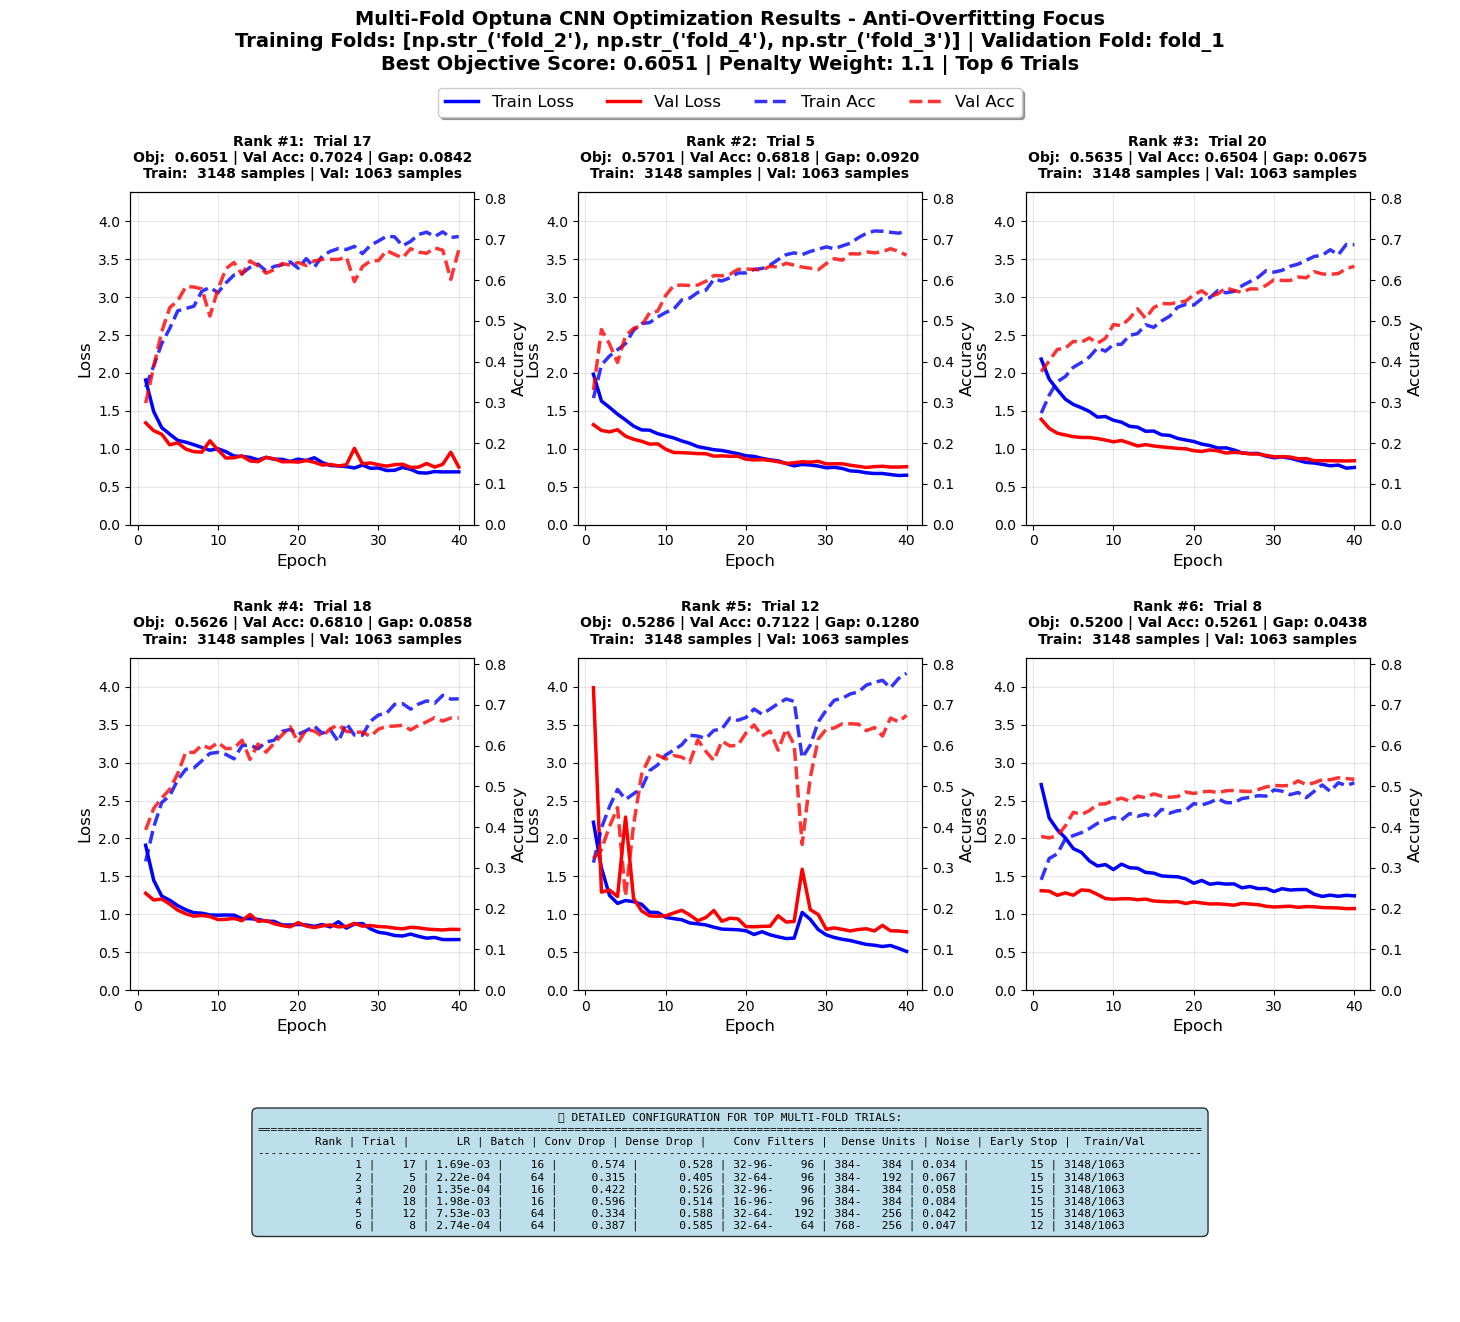

In [ ]:
# apply multi-fold optimization
best_params, study = classifier.optimize_cnn_with_optuna_multi_fold(
    num_trials=30,
    max_epochs=40,
    validation_fold='fold_1',  # Use fold_1 for validation, others for training
    overfitting_penalty_weight=1.1)

# Implementation
- Train final CNN model
- evaluate on 15% validation data and test set

In [ ]:
######################## Comprehensive Optimal Configuration Training Pipeline ###############################

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from collections import Counter
import os

def train_with_optimal_config_comprehensive(self, 
                                          config_path="optimal_config_optuna_multi_fold.pkl",
                                          validation_size=0.15,
                                          max_epochs=100,
                                          verbose=True,
                                          plot_results=True,
                                          save_plots=True,
                                          random_state=42):
    """
    Comprehensive training pipeline with optimal configuration
    
    Parameters:
    -----------
    config_path : str
        Path to saved optimal configuration (default: optimal_config_optuna.pkl)
    validation_size : float
        Fraction of training data to use for validation (default 0.15)
    max_epochs : int
        Maximum training epochs (default 100)
    verbose : bool
        Whether to show detailed output
    plot_results : bool
        Whether to create comprehensive plots
    save_plots : bool
        Whether to save plots to file
    random_state : int
        Random seed for reproducibility
    """
    
    print("🚀 COMPREHENSIVE OPTIMAL CONFIGURATION TRAINING PIPELINE")
    print("="*70)
    
    # Step 1: Load optimal configuration
    print(f"\n📁 Loading optimal configuration...")
    print(f"   Config path: {config_path}")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Configuration file not found: {config_path}")
    
    try:
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        
        print("✅ Configuration loaded successfully!")
        
        if verbose:
            print(f"\n📋 Optimal hyperparameters:")
            for key, value in config.items():
                print(f"  {key: <25}:  {value}")
                
    except Exception as e:
        print(f"❌ Error loading configuration: {e}")
        return None
    
    # Store configuration
    self.best_optuna_params = config
    
    # Step 2: Verify data availability
    print(f"\n🔍 Verifying data availability...")
    
    required_data = ['X_train_scaled', 'y_train_encoded', 'X_test_scaled', 'y_test_encoded']
    missing_data = [attr for attr in required_data if not hasattr(self, attr)]
    
    if missing_data: 
        raise ValueError(f"Missing data:  {missing_data}. Please run the full data pipeline first.")
    
    # Use original unbalanced training data
    X_train_original = self.X_train_scaled
    y_train_original = self.y_train_encoded
    X_test = self.X_test_scaled
    y_test = self.y_test_encoded
    
    print(f"✅ Data verified:")
    print(f"  Original training data:  {X_train_original.shape}")
    print(f"  Test data: {X_test.shape}")
    print(f"  Number of classes: {self.n_classes}")
    
    # Show original class distribution
    print(f"\n📊 Original training data class distribution:")
    original_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_original == i)
        percentage = (count / len(y_train_original)) * 100
        original_counts[i] = count
        print(f"  Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")
    
    # Step 3: Create train/validation split
    print(f"\n📊 Creating train/validation split...")
    print(f"  Validation size: {validation_size*100:.1f}% of training data")
    
    np.random.seed(random_state)
    
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_original, y_train_original,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_original
    )
    
    print(f"✅ Data splits created:")
    print(f"  Training split: {X_train_split.shape}")
    print(f"  Validation split: {X_val_split.shape}")
    print(f"  Test set: {X_test.shape}")
    
    # Step 4: Apply balancing to training split only
    print(f"\n⚖️ Applying class balancing to training split...")
    print(f"  Method: Over/undersampling to mean per cluster")
    print(f"  Note:  Validation and test sets keep natural distribution")
    
    # Calculate class distribution in training split
    train_class_counts = Counter(y_train_split)
    total_train_samples = len(y_train_split)
    n_clusters = len(train_class_counts)
    target_per_cluster = total_train_samples // n_clusters
    
    print(f"\n📊 Training split before balancing:")
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = train_class_counts.get(i, 0)
        print(f"  Class {i} ({class_name}): {count} samples")
    
    print(f"\n🎯 Target samples per cluster: {target_per_cluster}")
    
    # Balance classes to mean
    X_train_balanced_list = []
    y_train_balanced_list = []
    
    for class_id in range(self.n_classes):
        class_mask = y_train_split == class_id
        X_class = X_train_split[class_mask]
        y_class = y_train_split[class_mask]
        
        current_count = len(X_class)
        class_name = self.label_encoder.classes_[class_id]
        
        if current_count < target_per_cluster:
            # OVERSAMPLE:  randomly duplicate samples to reach target
            n_to_add = target_per_cluster - current_count
            oversample_indices = np.random.choice(len(X_class), size=n_to_add, replace=True)
            X_additional = X_class[oversample_indices]
            y_additional = y_class[oversample_indices]
            
            X_class_balanced = np.vstack([X_class, X_additional])
            y_class_balanced = np.concatenate([y_class, y_additional])
            
            print(f"  📈 Class {class_id} ({class_name}): {current_count} → {target_per_cluster} (+{n_to_add} oversampled)")
            
        elif current_count > target_per_cluster:
            # UNDERSAMPLE: randomly select subset to reach target
            undersample_indices = np.random.choice(len(X_class), size=target_per_cluster, replace=False)
            X_class_balanced = X_class[undersample_indices]
            y_class_balanced = y_class[undersample_indices]
            
            print(f"  📉 Class {class_id} ({class_name}): {current_count} → {target_per_cluster} (-{current_count - target_per_cluster} undersampled)")
            
        else: 
            # Already at target
            X_class_balanced = X_class
            y_class_balanced = y_class
            print(f"  ✅ Class {class_id} ({class_name}): {current_count} (no change needed)")
        
        X_train_balanced_list.append(X_class_balanced)
        y_train_balanced_list.append(y_class_balanced)
    
    # Combine all balanced classes
    X_train_final = np.vstack(X_train_balanced_list)
    y_train_final = np.concatenate(y_train_balanced_list)
    
    # Shuffle the balanced data
    shuffle_indices = np.random.permutation(len(X_train_final))
    X_train_final = X_train_final[shuffle_indices]
    y_train_final = y_train_final[shuffle_indices]
    
    print(f"\n✅ Final data summary:")
    print(f"  Training set (balanced): {X_train_final.shape}")
    print(f"  Validation set (natural): {X_val_split.shape}")
    print(f"  Test set (natural): {X_test.shape}")
    
    # Show final class distributions
    print(f"\n📋 Final class distributions:")
    
    # Training (balanced)
    print("  📊 Training set (BALANCED):")
    train_final_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_final == i)
        percentage = (count / len(y_train_final)) * 100
        train_final_counts[i] = count
        print(f"    Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")
    
    # Validation (natural)
    print("  📊 Validation set (NATURAL):")
    val_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_val_split == i)
        percentage = (count / len(y_val_split)) * 100
        val_counts[i] = count
        print(f"    Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")
    
    # Test (natural)
    print("  📊 Test set (NATURAL):")
    test_counts = {}
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_test == i)
        percentage = (count / len(y_test)) * 100
        test_counts[i] = count
        print(f"    Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")
    
    # Step 5: Convert to categorical
    y_train_final_cat = to_categorical(y_train_final, self.n_classes)
    y_val_split_cat = to_categorical(y_val_split, self.n_classes)
    y_test_cat = to_categorical(y_test, self.n_classes)
    
    # Step 6: Build optimized model
    print(f"\n🏗️ Building model with optimal configuration...")
    
    model = self.create_optuna_cnn_model(X_train_final.shape[1:], config)
    
    # Compile with optimal parameters
    optimizer = Adam(learning_rate=config["learning_rate"])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    if verbose:
        print(f"\n🏛️ Model architecture summary:")
        model.summary()
    
    # Setup callbacks with optimal parameters
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config["early_stop_patience"],
            restore_best_weights=True,
            verbose=1 if verbose else 0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config["lr_reduction_factor"],
            patience=config["lr_patience"],
            min_lr=1e-7,
            verbose=1 if verbose else 0
        )
    ]
    
    # Step 7: Train model
    print(f"\n🔥 Training model with optimal hyperparameters...")
    print(f"  📊 Max epochs: {max_epochs}")
    print(f"  📊 Batch size: {config['batch_size']}")
    print(f"  📊 Learning rate: {config['learning_rate']:.6f}")
    print(f"  📊 Early stop patience: {config['early_stop_patience']}")
    print(f"  📊 LR reduction factor: {config['lr_reduction_factor']}")
    
    history = model.fit(
        X_train_final, y_train_final_cat,
        validation_data=(X_val_split, y_val_split_cat),
        epochs=max_epochs,
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=1 if verbose else 0
    )
    
    epochs_trained = len(history.history['loss'])
    print(f"\n📊 Training completed after {epochs_trained} epochs")
    
    # Step 8: Comprehensive evaluation
    print(f"\n🎯 Comprehensive evaluation on all data sets...")
    
    # Training set evaluation (balanced data)
    train_loss, train_accuracy = model.evaluate(X_train_final, y_train_final_cat, verbose=0)
    y_train_pred_proba = model.predict(X_train_final, verbose=0)
    y_train_pred = np.argmax(y_train_pred_proba, axis=1)
    train_balanced_acc = balanced_accuracy_score(y_train_final, y_train_pred)
    train_macro_f1 = f1_score(y_train_final, y_train_pred, average='macro')
    
    # Validation set evaluation (natural data)
    val_loss, val_accuracy = model.evaluate(X_val_split, y_val_split_cat, verbose=0)
    y_val_pred_proba = model.predict(X_val_split, verbose=0)
    y_val_pred = np.argmax(y_val_pred_proba, axis=1)
    val_balanced_acc = balanced_accuracy_score(y_val_split, y_val_pred)
    val_macro_f1 = f1_score(y_val_split, y_val_pred, average='macro')
    
    # Test set evaluation (natural data) - FINAL PERFORMANCE
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_micro_f1 = f1_score(y_test, y_test_pred, average='micro')
    
    # Detailed classification reports
    train_report = classification_report(y_train_final, y_train_pred, target_names=self.label_encoder.classes_, output_dict=True)
    val_report = classification_report(y_val_split, y_val_pred, target_names=self.label_encoder.classes_, output_dict=True)
    test_report = classification_report(y_test, y_test_pred, target_names=self.label_encoder.classes_, output_dict=True)
    
    # Confusion matrices
    train_cm = confusion_matrix(y_train_final, y_train_pred)
    val_cm = confusion_matrix(y_val_split, y_val_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)
    
    # Calculate overfitting metrics
    accuracy_gap = train_accuracy - val_accuracy
    balanced_acc_gap = train_balanced_acc - val_balanced_acc
    loss_gap = val_loss - train_loss
    
    # Store comprehensive results
    results = {
        'model':  model,
        'history': history,
        'config_used': config,
        'epochs_trained': epochs_trained,
        
        # Training results (balanced data)
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'train_balanced_accuracy': train_balanced_acc,
        'train_macro_f1': train_macro_f1,
        'train_predictions': y_train_pred,
        'train_probabilities': y_train_pred_proba,
        'train_true':  y_train_final,
        'train_classification_report': train_report,
        'train_confusion_matrix':  train_cm,
        
        # Validation results (natural data)
        'val_loss':  val_loss,
        'val_accuracy': val_accuracy,
        'val_balanced_accuracy':  val_balanced_acc,
        'val_macro_f1':  val_macro_f1,
        'val_predictions': y_val_pred,
        'val_probabilities': y_val_pred_proba,
        'val_true': y_val_split,
        'val_classification_report': val_report,
        'val_confusion_matrix': val_cm,
        
        # Test results (natural data) - FINAL PERFORMANCE
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'test_macro_f1': test_macro_f1,
        'test_micro_f1': test_micro_f1,
        'test_predictions': y_test_pred,
        'test_probabilities': y_test_pred_proba,
        'test_true': y_test,
        'test_classification_report': test_report,
        'test_confusion_matrix': test_cm,
        
        # Overfitting analysis
        'accuracy_gap': accuracy_gap,
        'balanced_accuracy_gap': balanced_acc_gap,
        'loss_gap': loss_gap,
        
        # Data information
        'original_counts': original_counts,
        'train_balanced_counts': train_final_counts,
        'val_counts': val_counts,
        'test_counts': test_counts,
        'validation_size': validation_size,
        'target_per_cluster': target_per_cluster
    }
    
    self.optimal_training_results = results
    
    # Step 9: Print comprehensive results
    print(f"\n🏆 COMPREHENSIVE TRAINING RESULTS:")
    print(f"{'='*70}")
    print(f"{'Metric':<25} {'Training':<12} {'Validation':<12} {'Test':<12}")
    print(f"{'-'*70}")
    print(f"{'Loss':<25} {train_loss:<12.4f} {val_loss:<12.4f} {test_loss:<12.4f}")
    print(f"{'Accuracy':<25} {train_accuracy:<12.4f} {val_accuracy:<12.4f} {test_accuracy:<12.4f}")
    print(f"{'Balanced Accuracy':<25} {train_balanced_acc:<12.4f} {val_balanced_acc:<12.4f} {test_balanced_acc:<12.4f}")
    print(f"{'Macro F1-Score':<25} {train_macro_f1:<12.4f} {val_macro_f1:<12.4f} {test_macro_f1:<12.4f}")
    
    print(f"\n📊 OVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (Train - Val):     {accuracy_gap:+.4f}")
    print(f"  Balanced Acc Gap (Train - Val): {balanced_acc_gap:+.4f}")
    print(f"  Loss Gap (Val - Train):         {loss_gap:+.4f}")
    
    print(f"\n🎯 FINAL TEST PERFORMANCE (Primary Metric):")
    print(f"  Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  Test Macro F1-Score:     {test_macro_f1:.4f}")
    print(f"  Test Loss:              {test_loss:.4f}")
    
    # Step 10: Create comprehensive visualization
    if plot_results:
        print(f"\n📊 Creating comprehensive training visualization...")
        self.plot_optimal_training_results(results, save_plots)
    
    print(f"\n✅ COMPREHENSIVE OPTIMAL CONFIGURATION TRAINING COMPLETED!")
    print(f"📁 Results stored in: classifier. optimal_training_results")
    
    return results

### plot results ######

def plot_optimal_training_results(self, results, save_plots=True, figsize=(20, 16)):
    """Create comprehensive visualization for optimal training results"""
    
    print("🎨 Creating comprehensive result visualization...")
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.4, wspace=0.3)
    
    # Define epochs from history data
    epochs = range(1, len(results['history'].history['loss']) + 1)
    
    # 1. Learning Progress Overview
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Create a combined loss and accuracy plot
    ax1_twin = ax1.twinx()
    ax1_twin.set_ylim(0, 1)  # Forces accuracy axis to show 0-1 range
    
    # Plot loss on primary axis
    line1 = ax1.plot(epochs, results['history'].history['loss'], 'b-', linewidth=2, label='Train Loss')
    line2 = ax1.plot(epochs, results['history'].history['val_loss'], 'r-', linewidth=2, label='Val Loss')
    
    # Plot accuracy on secondary axis
    line3 = ax1_twin.plot(epochs, results['history'].history['accuracy'], 'b--', linewidth=2, alpha=0.7, label='Train Acc')
    line4 = ax1_twin.plot(epochs, results['history'].history['val_accuracy'], 'r--', linewidth=2, alpha=0.7, label='Val Acc')
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='black')
    ax1_twin.set_ylabel('Accuracy', color='gray')
    ax1.set_title('Learning Progress Overview', fontweight='bold', fontsize=11)
    
    # Combine legends
    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', fontsize=8)
    
    ax1.grid(True, alpha=0.3)
    
    # 2. Performance Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    metrics = ['Accuracy', 'Balanced Acc', 'Macro F1']
    train_scores = [results['train_accuracy'], results['train_balanced_accuracy'], results['train_macro_f1']]
    val_scores = [results['val_accuracy'], results['val_balanced_accuracy'], results['val_macro_f1']]
    test_scores = [results['test_accuracy'], results['test_balanced_accuracy'], results['test_macro_f1']]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    bars1 = ax2.bar(x - width, train_scores, width, label='Training (Balanced)', alpha=0.8, color='blue')
    bars2 = ax2.bar(x, val_scores, width, label='Validation (Natural)', alpha=0.8, color='orange')
    bars3 = ax2.bar(x + width, test_scores, width, label='Test (Natural)', alpha=0.8, color='green')
    
    ax2.set_title('Performance Comparison', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Metrics')
    ax2.set_ylabel('Score')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.legend(fontsize=9, loc = 'lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    # Add value labels on bars
    def autolabel(ax, bars):
        for bar in bars:  
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    autolabel(ax2, bars1)
    autolabel(ax2, bars2)
    autolabel(ax2, bars3)
    
    # 3. Class Distribution Comparison
    ax3 = fig.add_subplot(gs[0, 2])
    classes = list(range(len(self.label_encoder.classes_)))
    original_counts = [results['original_counts'][i] for i in classes]
    train_counts = [results['train_balanced_counts'][i] for i in classes]
    val_counts = [results['val_counts'][i] for i in classes]
    test_counts = [results['test_counts'][i] for i in classes]
    
    x_classes = np.arange(len(classes))
    width_classes = 0.2
    
    ax3.bar(x_classes - 1.5*width_classes, original_counts, width_classes, label='Original', alpha=0.7, color='gray')
    ax3.bar(x_classes - 0.5*width_classes, train_counts, width_classes, label='Training (Balanced)', alpha=0.8, color='blue')
    ax3.bar(x_classes + 0.5*width_classes, val_counts, width_classes, label='Validation', alpha=0.8, color='orange')
    ax3.bar(x_classes + 1.5*width_classes, test_counts, width_classes, label='Test', alpha=0.8, color='green')
    
    ax3.set_title('Class Distribution Comparison', fontweight='bold', fontsize=11)
    ax3.set_xlabel('Class')
    ax3.set_ylabel('Sample Count')
    ax3.set_xticks(x_classes)
    ax3.set_xticklabels([f'Class {i}' for i in classes])
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Training Set Confusion Matrix
    ax4 = fig.add_subplot(gs[1, 0])
    train_cm_norm = results['train_confusion_matrix'].astype('float') / results['train_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(train_cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax4,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax4.set_title(f'Training Set (Balanced)\nBalanced Accuracy: {results["train_balanced_accuracy"]:.3f}', 
                  fontweight='bold', fontsize=11)
    ax4.set_xlabel('Predicted')
    ax4.set_ylabel('True')
    
    # 5. Validation Set Confusion Matrix
    ax5 = fig.add_subplot(gs[1, 1])
    val_cm_norm = results['val_confusion_matrix'].astype('float') / results['val_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(val_cm_norm, annot=True, fmt='.2f', cmap='Oranges', ax=ax5,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax5.set_title(f'Validation Set (Natural)\nBalanced Accuracy: {results["val_balanced_accuracy"]:.3f}', 
                  fontweight='bold', fontsize=11)
    ax5.set_xlabel('Predicted')
    ax5.set_ylabel('True')
    
    # 6. Test Set Confusion Matrix
    ax6 = fig.add_subplot(gs[1, 2])
    test_cm_norm = results['test_confusion_matrix'].astype('float') / results['test_confusion_matrix'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(test_cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax6,
                xticklabels=self.label_encoder.classes_, yticklabels=self.label_encoder.classes_)
    ax6.set_title(f'Test Set (Natural)\nBalanced Accuracy: {results["test_balanced_accuracy"]:.3f}', 
                  fontweight='bold', fontsize=11)
    ax6.set_xlabel('Predicted')
    ax6.set_ylabel('True')
    
    # 7. Prediction Confidence Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    val_max_probs = np.max(results['val_probabilities'], axis=1)
    test_max_probs = np.max(results['test_probabilities'], axis=1)
    
    ax7.hist(val_max_probs, bins=20, alpha=0.6, label=f'Validation\n(mean: {np.mean(val_max_probs):.3f})', 
             color='orange', density=True)
    ax7.hist(test_max_probs, bins=20, alpha=0.6, label=f'Test\n(mean: {np.mean(test_max_probs):.3f})', 
             color='green', density=True)
    ax7.set_title('Prediction Confidence Distribution', fontweight='bold', fontsize=11)
    ax7.set_xlabel('Max Prediction Probability')
    ax7.set_ylabel('Density')
    ax7.legend(fontsize=9)
    ax7.grid(True, alpha=0.3)
    
    # 8. Configuration and Results Summary
    ax8 = fig.add_subplot(gs[2, 1:3])
    ax8.axis('off')
    
    # Create comprehensive summary text
    config = results['config_used']
    summary_text = f"""OPTIMAL CONFIGURATION TRAINING RESULTS SUMMARY

MODEL CONFIGURATION:
   • Learning Rate:  {config['learning_rate']:.2e}    • Batch Size: {config['batch_size']}    • Conv Dropout: {config['dropout_rate_conv']:.3f}    • Dense Dropout: {config['dropout_rate_dense']:.3f}
   • Conv Filters: [{config['conv_filters_1']}, {config['conv_filters_2']}, {config['conv_filters_3']}]    • Dense Units: [{config['dense_units_1']}, {config['dense_units_2']}]    • Epochs Trained: {results['epochs_trained']}

FINAL PERFORMANCE (Test Set - Natural Distribution):
   • Balanced Accuracy: {results['test_balanced_accuracy']:.4f}    • Macro F1-Score: {results['test_macro_f1']:.4f}    • Micro F1-Score: {results['test_micro_f1']:.4f}    • Loss: {results['test_loss']:.4f}

DATA STRATEGY:
   • Training:  Balanced to {results['target_per_cluster']} samples per class ({results['train_balanced_counts'][0]} × {len(results['train_balanced_counts'])} = {sum(results['train_balanced_counts'].values())} total)
   • Validation: Natural distribution ({len(results['val_true'])} samples, {results['validation_size']*100:.0f}% of original training)
   • Test: Natural distribution ({len(results['test_true'])} samples, unseen during training)

OVERFITTING ANALYSIS:
   • Accuracy Gap (Train-Val): {results['accuracy_gap']:+.4f}    • Balanced Acc Gap (Train-Val): {results['balanced_accuracy_gap']:+.4f}    • Loss Gap (Val-Train): {results['loss_gap']:+.4f}"""
    
    ax8.text(0.02, 0.95, summary_text, transform=ax8.transAxes, fontsize=10,
              verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.8))
    
    # Add main title
    fig.suptitle('Optimal Configuration Training Results - Comprehensive Analysis', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    # Save plot if requested
    if save_plots: 
        save_path = '../Data/optimal_training_results_comprehensive.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"💾 Comprehensive results plot saved to: {save_path}")
    
    plt.show()

# Add functions to class
HeatmapCNNClassifier.train_with_optimal_config_comprehensive = train_with_optimal_config_comprehensive
HeatmapCNNClassifier.plot_optimal_training_results = plot_optimal_training_results

print("✅ Comprehensive Optimal Configuration Training Pipeline loaded!")
print("\n🚀 USAGE:")
print("results = classifier.train_with_optimal_config_comprehensive(")
print("    config_path='../Data/optimal_config_optuna_multi_fold.pkl',")
print("    validation_size=0.15,")
print("    max_epochs=100,")
print("    plot_results=True,")
print("    save_plots=True")
print(")")

# Example usage: 
# results = classifier.train_with_optimal_config_comprehensive()

✅ Comprehensive Optimal Configuration Training Pipeline loaded!

🚀 USAGE:
results = classifier.train_with_optimal_config_comprehensive(
    config_path='../Data/optimal_config_optuna_multi_fold.pkl',
    validation_size=0.15,
    max_epochs=100,
    plot_results=True,
    save_plots=True
)


🚀 COMPREHENSIVE OPTIMAL CONFIGURATION TRAINING PIPELINE

📁 Loading optimal configuration...
   Config path: ../Data/optimal_config_optuna_multi_fold.pkl
✅ Configuration loaded successfully!

📋 Optimal hyperparameters:
  learning_rate            :  0.0016884427613958475
  batch_size               :  16
  dropout_rate_conv        :  0.573556424394708
  dropout_rate_dense       :  0.5281325145933764
  conv_filters_1           :  32
  conv_filters_2           :  96
  conv_filters_3           :  96
  dense_units_1            :  384
  dense_units_2            :  384
  noise_level              :  0.03403026488762276
  block_size               :  3
  lr_reduction_factor      :  0.36380030320115525
  lr_patience              :  6
  early_stop_patience      :  15

🔍 Verifying data availability...
✅ Data verified:
  Original training data:  (4214, 46, 46, 3)
  Test data: (1405, 46, 46, 3)
  Number of classes: 4

📊 Original training data class distribution:
  Class 0 (0): 1581 samples (37.5%)
  Cl

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block_gaussian_noise_21         │ (None, 46, 46, 3)      │             0 │
│ (BlockGaussianNoise)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_126 (Conv2D)             │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 23, 23, 96)     │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 23, 23, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 23, 23, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 11, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_130 (Conv2D)             │ (None, 11, 11, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 11, 11, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_131 (Conv2D)             │ (None, 11, 11, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 384)            │       921,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_108 (Dropout)           │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 384)            │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_109 (Dropout)           │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,360,804 (5.19 MB)

 Trainable params: 1,359,588 (5.19 MB)

 Non-trainable params: 1,216 (4.75 KB)


🔥 Training model with optimal hyperparameters...
  📊 Max epochs: 100
  📊 Batch size: 16
  📊 Learning rate: 0.001688
  📊 Early stop patience: 15
  📊 LR reduction factor: 0.36380030320115525
Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3274 - loss: 1.8710 - val_accuracy: 0.4692 - val_loss: 1.1620 - learning_rate: 0.0017
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4101 - loss: 1.4266 - val_accuracy: 0.4202 - val_loss: 1.2636 - learning_rate: 0.0017
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4704 - loss: 1.2216 - val_accuracy: 0.5197 - val_loss: 1.0329 - learning_rate: 0.0017
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5053 - loss: 1.1198 - val_accuracy: 0.5561 - val_loss: 0.9846 - learning_rate: 0.0017
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5444 - loss: 1.0543 - val_accuracy: 0.5924 - val_loss: 0.9103 - learning_rate: 0.0017
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━

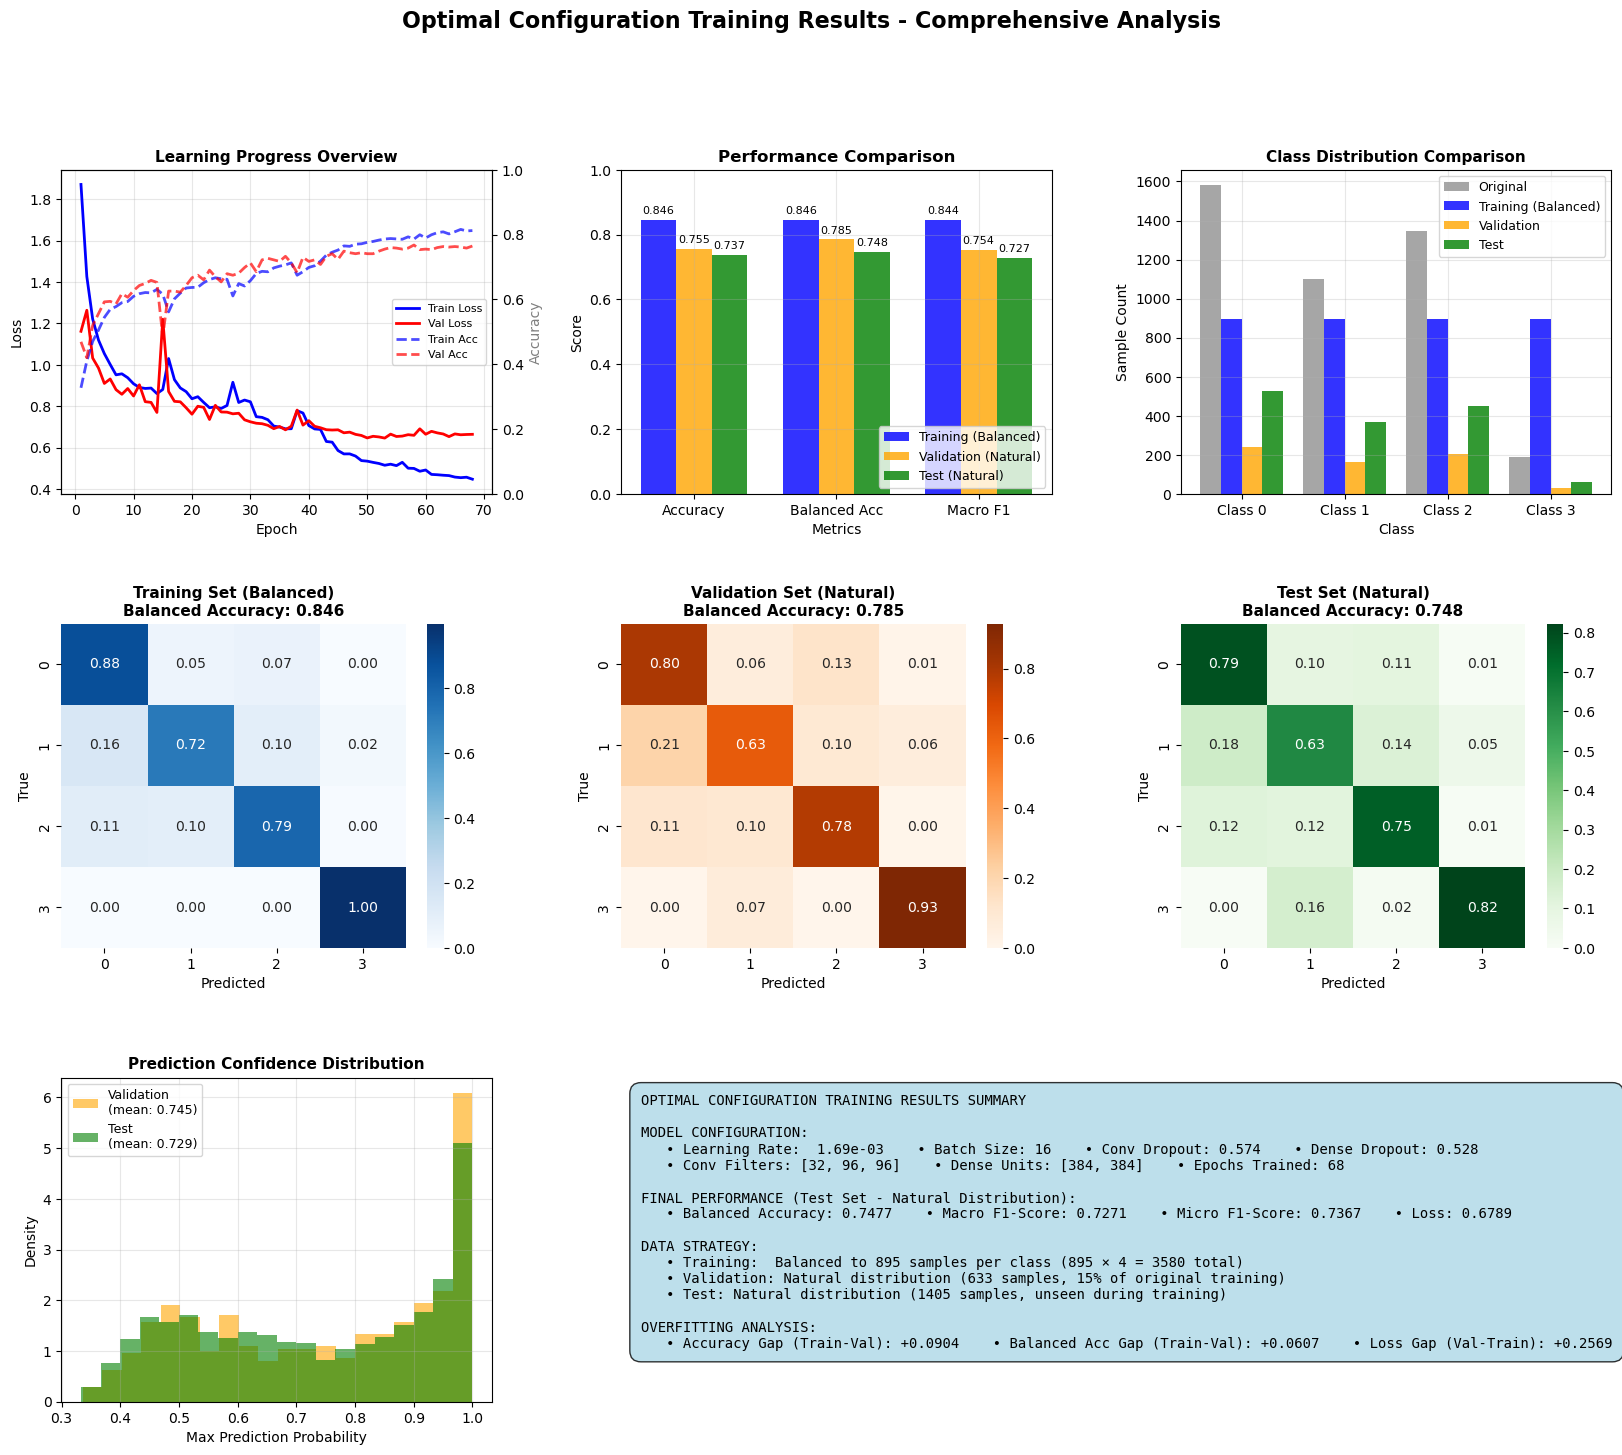


✅ COMPREHENSIVE OPTIMAL CONFIGURATION TRAINING COMPLETED!
📁 Results stored in: classifier. optimal_training_results
Final test balanced accuracy: 0.7477
Final test macro F1: 0.7271


In [ ]:
# Run the complete pipeline
results = classifier.train_with_optimal_config_comprehensive(
    config_path='../Data/optimal_config_optuna_multi_fold.pkl',
    validation_size=0.15,
    max_epochs=100,
    plot_results=True,
    save_plots=True
)

# Access results
print(f"Final test balanced accuracy: {results['test_balanced_accuracy']:.4f}")
print(f"Final test macro F1: {results['test_macro_f1']:.4f}")

In [ ]:
# save model to file
model_save_path = '../Data/optimal_cnn_model_multi_fold.h5'
results['model'].save(model_save_path)

# add results to classifier object
classifier.results = results

In [ ]:
######################## Clean Model Save/Load - Adapted for Comprehensive Results ###############################

import os
import pickle
import tensorflow as tf
import numpy as np

def save_clean_model_from_comprehensive_results(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Save model without BlockGaussianNoise layer from comprehensive training results
    """
    original_model = self.results['model']
    results = self.results
    
    print(f"💾 Saving clean model (without custom layers) to {save_directory}...")
    print(f"📊 Source:  Comprehensive balanced training results")
    
    # Create save directory if it doesn't exist
    os.makedirs(save_directory, exist_ok=True)
    
    try:
        # Step 1: Create clean model without BlockGaussianNoise
        print("🛠️ Creating clean model...")
        
        # Get input shape (remove batch dimension)
        input_shape = original_model.input_shape[1:]
        print(f"  Input shape: {input_shape}")
        
        # Create new input layer
        clean_input = tf.keras.layers.Input(shape=input_shape, name='clean_input')
        x = clean_input
        
        # Copy all layers except BlockGaussianNoise
        layers_copied = 0
        layers_skipped = 0
        
        for i, layer in enumerate(original_model.layers):
            layer_name = layer.__class__.__name__
            
            # Skip BlockGaussianNoise layer
            if layer_name == 'BlockGaussianNoise':  
                print(f"  Skipping layer {i}: {layer_name}")
                layers_skipped += 1
                continue
            
            # Skip Input layer (we created our own)
            if layer_name == 'InputLayer':
                print(f"  Skipping layer {i}:  {layer_name} (using custom input)")
                layers_skipped += 1
                continue
            
            try:
                # Apply layer to current tensor
                x = layer(x)
                layers_copied += 1
                print(f"  Copied layer {i}: {layer_name}")
            except Exception as e:
                print(f"  ⚠️ Could not copy layer {i} ({layer_name}): {e}")
                layers_skipped += 1
                continue
        
        print(f"  ✅ Successfully copied {layers_copied} layers")
        print(f"  ⏭️ Skipped {layers_skipped} layers (custom layers + input)")
        
        # Step 2: Create clean model
        clean_model = tf.keras.Model(inputs=clean_input, outputs=x, name='clean_balanced_model')
        
        # Compile clean model with same optimizer as original training
        config_used = results. get('config_used', {})
        learning_rate = config_used.get('learning_rate', 0.001)
        
        clean_model.compile(
            optimizer=tf.keras. optimizers.Adam(learning_rate=learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print(f"  📊 Clean model shape: {clean_model.input_shape} -> {clean_model.output_shape}")
        
        # Step 3: Test clean model predictions
        print("🧪 Testing clean model...")
        dummy_input = tf.random.normal((1,) + input_shape)
        
        original_pred = original_model.predict(dummy_input, verbose=0)
        clean_pred = clean_model.predict(dummy_input, verbose=0)
        
        # Compare predictions (should be very similar since BlockGaussianNoise is off during inference)
        pred_diff = tf.reduce_max(tf.abs(original_pred - clean_pred)).numpy()
        print(f"  📊 Max prediction difference: {pred_diff:.8f}")
        
        if pred_diff < 0.001:
            print("  ✅ Clean model predictions match original")
        else:
            print("  ⚠️ Some difference in predictions (may be OK)")
        
        # Step 4: Save clean model
        clean_model_path = os.path.join(save_directory, f'{model_name}.h5')
        clean_model.save(clean_model_path)
        print(f"✅ Clean model saved:  {clean_model_path}")
        
        # Step 5: Create comprehensive metadata from comprehensive results
        metadata = {
            'model_name': model_name,
            'clean_model_path': clean_model_path,
            'training_approach': 'balanced_leak_free',
            'timestamp': tf.timestamp().numpy(),
            
            # Configuration used
            'config_used':  config_used,
            'epochs_trained': results.get('epochs_trained', 0),
            'validation_size': results.get('validation_size', 0.15),
            
            # Model architecture info
            'input_shape': input_shape,
            'output_shape': clean_model.output_shape[1:],
            'n_classes': getattr(self, 'n_classes', 4),
            'label_encoder_classes': getattr(self. label_encoder, 'classes_', []).tolist() if hasattr(self, 'label_encoder') else [],
            
            # Performance on all sets
            'performance':  {
                'training':  {
                    'accuracy': results. get('train_accuracy', 0),
                    'balanced_accuracy': results.get('train_balanced_accuracy', 0),
                    'macro_f1': results.get('train_macro_f1', 0),
                    'loss': results.get('train_loss', 0),
                    'data_type': 'balanced'
                },
                'validation': {
                    'accuracy': results.get('val_accuracy', 0),
                    'balanced_accuracy': results.get('val_balanced_accuracy', 0),
                    'macro_f1': results.get('val_macro_f1', 0),
                    'loss': results.get('val_loss', 0),
                    'data_type': 'natural'
                },
                'test': {
                    'accuracy': results.get('test_accuracy', 0),
                    'balanced_accuracy': results.get('test_balanced_accuracy', 0),
                    'macro_f1': results.get('test_macro_f1', 0),
                    'micro_f1': results.get('test_micro_f1', 0),
                    'loss':  results.get('test_loss', 0),
                    'data_type': 'natural'
                }
            },
            
            # Data characteristics
            'data_info': {
                'train_samples': len(results. get('train_true', [])),
                'val_samples': len(results.get('val_true', [])),
                'test_samples': len(results.get('test_true', [])),
                'train_counts': results.get('train_counts', {}),
                'val_counts': results.get('val_counts', {}),
                'test_counts': results.get('test_counts', {}),
                'balanced_training':  results.get('balanced_training', True),
                'leak_free':  results.get('leak_free', True)
            }
        }
        
        metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"✅ Comprehensive metadata saved: {metadata_path}")
        
        # Step 6: Save model summary
        summary_path = os.path.join(save_directory, f'{model_name}_summary.txt')
        with open(summary_path, 'w') as f:
            f.write("CLEAN MODEL SUMMARY\n")
            f.write("="*50 + "\n")
            f.write(f"Model Name: {model_name}\n")
            f.write(f"Training Approach:  Balanced + Leak-Free\n")
            f.write(f"Epochs Trained: {results.get('epochs_trained', 0)}\n")
            f.write(f"Validation Size: {results.get('validation_size', 0.15)*100:.1f}%\n\n")
            
            f.write("FINAL PERFORMANCE:\n")
            f.write(f"  Test Accuracy: {results.get('test_accuracy', 0):.4f}\n")
            f.write(f"  Test Balanced Accuracy: {results.get('test_balanced_accuracy', 0):.4f}\n")
            f.write(f"  Test Macro F1: {results.get('test_macro_f1', 0):.4f}\n")
            f.write(f"  Test Micro F1: {results.get('test_micro_f1', 0):.4f}\n\n")
            
            f.write("DATA CHARACTERISTICS:\n")
            f.write(f"  Training: {len(results.get('train_true', []))} samples (BALANCED)\n")
            f.write(f"  Validation:  {len(results.get('val_true', []))} samples (NATURAL)\n")
            f.write(f"  Test: {len(results.get('test_true', []))} samples (NATURAL)\n")
            f.write(f"  No data leakage:  {results.get('leak_free', True)}\n\n")
            
            f.write("MODEL INFO:\n")
            f.write(f"  Input Shape: {input_shape}\n")
            f.write(f"  Output Shape: {clean_model.output_shape}\n")
            f.write(f"  Number of Classes: {getattr(self, 'n_classes', 4)}\n")
            f.write(f"  Layers Copied: {layers_copied}\n")
            f.write(f"  Custom Layers Removed: {layers_skipped}\n")
        
        print(f"✅ Model summary saved: {summary_path}")
        
        print(f"\n📁 CLEAN MODEL PACKAGE SAVED:")
        print(f"  🎯 Model file: {clean_model_path}")
        print(f"  📋 Metadata: {metadata_path}")
        print(f"  📝 Summary: {summary_path}")
        print(f"  🧠 Ready for SHAP analysis!")
        
        return {
            'model_path': clean_model_path,
            'metadata_path': metadata_path,
            'summary_path': summary_path,
            'model':  clean_model,
            'metadata': metadata
        }
        
    except Exception as e:  
        print(f"❌ Failed to create clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def load_clean_balanced_model(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Load clean model saved from comprehensive training results
    """
    
    print(f"📂 Loading clean model from comprehensive training...")
    
    # Step 1: Load metadata
    metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
    try:
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        print("✅ Comprehensive metadata loaded")
        
        # Print key performance info
        test_perf = metadata['performance']['test']
        print(f"  📊 Original test performance:")
        print(f"    Balanced Accuracy: {test_perf['balanced_accuracy']:.4f}")
        print(f"    Macro F1: {test_perf['macro_f1']:.4f}")
        print(f"    Training:  {metadata['data_info']['train_samples']} balanced samples")
        print(f"    Test: {metadata['data_info']['test_samples']} natural samples")
        
    except Exception as e:
        print(f"⚠️ Could not load metadata: {e}")
        metadata = None
    
    # Step 2: Load clean model
    clean_model_path = os. path.join(save_directory, f'{model_name}.h5')
    
    try:
        model = tf.keras.models.load_model(clean_model_path)
        print(f"✅ Clean model loaded from:  {clean_model_path}")
        print(f"  📊 Model shape: {model.input_shape} -> {model.output_shape}")
        
        # Step 3: Store for analysis (compatible with both old and new systems)
        # Store in both locations for compatibility
        if not hasattr(self, 'test_results_optimized'):
            self.test_results_optimized = {}
        if not hasattr(self, 'comprehensive_results'):
            self.comprehensive_results = {}
            
        self.test_results_optimized['model'] = model
        self.comprehensive_results['model'] = model
        
        # Store metadata if available
        if metadata:
            self.loaded_model_metadata = metadata
            
            # Restore label encoder if needed
            if metadata['label_encoder_classes'] and not hasattr(self, 'label_encoder'):
                from sklearn.preprocessing import LabelEncoder
                self.label_encoder = LabelEncoder()
                self.label_encoder.classes_ = np.array(metadata['label_encoder_classes'])
            
            # Restore n_classes
            if not hasattr(self, 'n_classes'):
                self.n_classes = metadata['n_classes']
        
        # Step 4: Test model
        print("🧪 Testing loaded model...")
        input_shape = model.input_shape[1:]
        dummy_input = tf.random.normal((1,) + input_shape)
        test_output = model.predict(dummy_input, verbose=0)
        
        print(f"  ✅ Model test successful")
        print(f"  📊 Output shape: {test_output.shape}")
        print(f"  📊 Output sum: {test_output.sum():.6f} (should be ~1.0 for probabilities)")
        
        print(f"\n🎯 Clean model ready for analysis!")
        print(f"  • SHAP analysis:  aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()")
        print(f"  • Model source:  Balanced training + Leak-free evaluation")
        
        return True
        
    except FileNotFoundError:
        print(f"❌ Clean model file not found: {clean_model_path}")
        print(f"Make sure you saved the model first using save_clean_model_from_comprehensive_results()")
        return False
    except Exception as e: 
        print(f"❌ Failed to load clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def print_saved_model_info(self, save_directory='../Data/', model_name='clean_balanced_model'):
    """
    Print information about saved clean model without loading it
    """
    
    metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
    summary_path = os.path. join(save_directory, f'{model_name}_summary.txt')
    
    print(f"📋 SAVED MODEL INFORMATION:  {model_name}")
    print("="*60)
    
    # Load and print metadata
    try:
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        
        print(f"✅ Model saved successfully")
        print(f"📊 Training approach: {metadata. get('training_approach', 'Unknown')}")
        print(f"🕐 Epochs trained: {metadata.get('epochs_trained', 0)}")
        
        # Performance summary
        print(f"\n📈 PERFORMANCE SUMMARY:")
        for set_name, perf in metadata['performance'].items():
            print(f"  {set_name. capitalize()} ({perf['data_type']}):")
            print(f"    Balanced Accuracy: {perf['balanced_accuracy']:.4f}")
            print(f"    Macro F1: {perf['macro_f1']:.4f}")
        
        # Data info
        data_info = metadata['data_info']
        print(f"\n📊 DATA CHARACTERISTICS:")
        print(f"  Training:  {data_info['train_samples']} samples (balanced)")
        print(f"  Validation: {data_info['val_samples']} samples (natural)")
        print(f"  Test: {data_info['test_samples']} samples (natural)")
        print(f"  Leak-free: {data_info['leak_free']}")
        
        print(f"\n📁 FILES:")
        print(f"  Model:  {metadata['clean_model_path']}")
        print(f"  Metadata:  {metadata_path}")
        
    except FileNotFoundError:
        print(f"❌ No saved model found: {metadata_path}")
    except Exception as e: 
        print(f"❌ Error reading metadata: {e}")
    
    # Print summary file if it exists
    try:
        with open(summary_path, 'r') as f:
            print(f"\n📝 SUMMARY FILE CONTENT:")
            print("-" * 30)
            print(f.read())
    except FileNotFoundError:
        pass

# Add functions to class
HeatmapCNNClassifier.save_clean_model_from_comprehensive_results = save_clean_model_from_comprehensive_results
HeatmapCNNClassifier.load_clean_balanced_model = load_clean_balanced_model
HeatmapCNNClassifier.print_saved_model_info = print_saved_model_info

print("✅ Adapted clean model save/load functions loaded!")
print("\nAdapted for comprehensive training results:")
print("\n1. Save clean model:")
print("   save_result = classifier.save_clean_model_from_comprehensive_results()")
print("\n2. Load clean model:")
print("   success = classifier.load_clean_balanced_model()")
print("\n3. Check saved model info:")
print("   classifier.print_saved_model_info()")

✅ Adapted clean model save/load functions loaded!

Adapted for comprehensive training results:

1. Save clean model:
   save_result = classifier.save_clean_model_from_comprehensive_results()

2. Load clean model:
   success = classifier.load_clean_balanced_model()

3. Check saved model info:
   classifier.print_saved_model_info()


In [ ]:
# 1. Save your trained clean model (after comprehensive training)
save_result = classifier.save_clean_model_from_comprehensive_results(
    save_directory='../Data/',
    model_name='clean_balanced_model_4_clusters'
)

💾 Saving clean model (without custom layers) to ../Data/...
📊 Source:  Comprehensive balanced training results
🛠️ Creating clean model...
  Input shape: (46, 46, 3)
  Skipping layer 0: BlockGaussianNoise
  Copied layer 1: Conv2D
  Copied layer 2: BatchNormalization
  Copied layer 3: Conv2D
  Copied layer 4: MaxPooling2D
  Copied layer 5: Dropout
  Copied layer 6: Conv2D
  Copied layer 7: BatchNormalization
  Copied layer 8: Conv2D
  Copied layer 9: MaxPooling2D
  Copied layer 10: Dropout
  Copied layer 11: Conv2D
  Copied layer 12: BatchNormalization
  Copied layer 13: Conv2D
  Copied layer 14: MaxPooling2D
  Copied layer 15: Dropout
  Copied layer 16: Flatten
  Copied layer 17: Dense
  Copied layer 18: BatchNormalization
  Copied layer 19: Dropout
  Copied layer 20: Dense
  Copied layer 21: Dropout
  Copied layer 22: Dense
  ✅ Successfully copied 22 layers
  ⏭️ Skipped 1 layers (custom layers + input)
  📊 Clean model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing clean model...
  📊 M

# SHAP analysis

In [ ]:
######################## Optimized SHAP Analysis - Updated for Clean Balanced Model ###############################

import time
import os
import pickle
import numpy as np
import shap
import tensorflow as tf
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def calculate_all_samples_shap_with_clean_balanced_model(self, 
                                                        model_directory='../Data/', 
                                                        model_name='clean_balanced_model_4_clusters',
                                                        background_samples=200,
                                                        batch_size=100,
                                                        save_interval=5,
                                                        max_samples_per_cluster=1000,
                                                        random_state=42):
    """
    Optimized SHAP calculation using clean balanced model
    """
    
    print("🚀 Starting OPTIMIZED SHAP Analysis with Clean Balanced Model")
    print("="*70)
    print(f"⚡ Optimizations:")
    print(f"  • Model source: Clean balanced model (no custom layers)")
    print(f"  • Background samples: {background_samples}")
    print(f"  • Batch size: {batch_size}")  
    print(f"  • Max samples per cluster: {max_samples_per_cluster}")
    print(f"  • Save interval:  {save_interval}")
    
    # Step 1: Create save directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"../Data/shap_results_balanced_model_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"📁 Save directory: {save_dir}")
    
    # Step 2: Load clean balanced model
    print(f"\n🔄 Loading clean balanced model...")
    print(f"  Model path: {model_directory}")
    print(f"  Model name:  {model_name}")
    
    load_success = self.load_clean_balanced_model(model_directory, model_name)
    
    if not load_success:
        print("❌ Failed to load clean balanced model")
        return None, None
    
    # Get model from the loaded results
    if hasattr(self, 'comprehensive_results') and 'model' in self.comprehensive_results:
        model = self.comprehensive_results['model']
        print("✅ Model loaded from comprehensive_results")
    elif hasattr(self, 'test_results_optimized') and 'model' in self.test_results_optimized:
        model = self.test_results_optimized['model']
        print("✅ Model loaded from test_results_optimized")
    else:
        print("❌ No model found after loading")
        return None, None
    
    # Get model info from metadata if available
    model_info = {}
    if hasattr(self, 'loaded_model_metadata'):
        metadata = self.loaded_model_metadata
        model_info = {
            'training_approach': metadata.get('training_approach', 'balanced_leak_free'),
            'epochs_trained': metadata.get('epochs_trained', 0),
            'test_performance': metadata.get('performance', {}).get('test', {}),
            'balanced_training':  metadata.get('data_info', {}).get('balanced_training', True)
        }
        
        print(f"📊 Model info from metadata:")
        print(f"  Training approach: {model_info['training_approach']}")
        print(f"  Epochs trained: {model_info['epochs_trained']}")
        if 'balanced_accuracy' in model_info['test_performance']:
            print(f"  Test balanced accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}")
    
    print(f"📊 Model loaded:  {model. input_shape} -> {model.output_shape}")
    
    # Step 3: Verify data availability and prepare
    print(f"\n📊 Preparing data...")
    
    required_data = ['X_train_scaled', 'X_test_scaled', 'y_train_encoded', 'y_test_encoded']
    missing_data = [attr for attr in required_data if not hasattr(self, attr)]
    
    if missing_data:
        raise ValueError(f"Missing required data:  {missing_data}")
    
    X_all = np.concatenate([self.X_train_scaled, self.X_test_scaled], axis=0)
    y_all = np.concatenate([self.y_train_encoded, self.y_test_encoded], axis=0)
    
    print(f"📈 Total available data: {X_all.shape}")
    print(f"📊 Class distribution:  {Counter(y_all)}")
    
    # Step 4: Setup explainer with background samples
    print(f"\n🧠 Setting up SHAP explainer with {background_samples} background samples...")
    np.random.seed(random_state)
    
    background_indices = np.random.choice(len(X_all), size=background_samples, replace=False)
    background_data = X_all[background_indices]
    
    print(f"📊 Background data shape: {background_data.shape}")
    
    explainer = shap.DeepExplainer(model, background_data)
    print("✅ SHAP explainer created successfully")
    
    # Step 5: Process clusters with sampling
    all_results = {}
    overall_start_time = time.time()
    
    for cluster_id in range(self.n_classes):  # Use actual number of classes
        print(f"\n🔍 Processing Cluster {cluster_id}...")
        
        cluster_mask = y_all == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            print(f"  ⚠️ No samples found for Cluster {cluster_id}")
            continue
            
        # Sample if too many samples
        if len(cluster_indices) > max_samples_per_cluster:
            sampled_indices = np.random. choice(
                cluster_indices, 
                size=max_samples_per_cluster, 
                replace=False
            )
            cluster_samples = X_all[sampled_indices]
            print(f"  📊 Using {max_samples_per_cluster}/{len(cluster_indices)} samples (sampled)")
        else:
            cluster_samples = X_all[cluster_indices]
            print(f"  📊 Using all {len(cluster_samples)} samples")
        
        n_samples = len(cluster_samples)
        total_batches = (n_samples - 1) // batch_size + 1
        
        print(f"  🔄 Processing {total_batches} batches (size {batch_size})...")
        
        cluster_start_time = time.time()
        cluster_shap_values = []
        successful_batches = 0
        
        for batch_idx in range(0, n_samples, batch_size):
            batch_end = min(batch_idx + batch_size, n_samples)
            batch_samples = cluster_samples[batch_idx:batch_end]
            batch_number = batch_idx // batch_size + 1
            
            try:
                # Calculate SHAP values
                batch_shap = explainer.shap_values(batch_samples)
                
                # Handle different SHAP output formats
                if isinstance(batch_shap, list):
                    # Multi-class output:  use SHAP values for current cluster
                    batch_shap_cluster = batch_shap[cluster_id]
                else:
                    batch_shap_cluster = batch_shap
                
                # Handle shape issues (sometimes 5D output)
                if len(batch_shap_cluster. shape) == 5 and batch_shap_cluster. shape[-1] == self.n_classes:
                    batch_shap_cluster = batch_shap_cluster[: , :, :, : , cluster_id]
                
                cluster_shap_values.append(batch_shap_cluster)
                successful_batches += 1
                
                # Progress update
                if batch_number % save_interval == 0 or batch_number == total_batches:
                    elapsed = time.time() - cluster_start_time
                    progress = (batch_number / total_batches) * 100
                    rate = batch_number / elapsed * 60 if elapsed > 0 else 0
                    eta_minutes = (total_batches - batch_number) / (batch_number / elapsed) / 60 if batch_number > 0 and elapsed > 0 else 0
                    
                    print(f"    📈 Batch {batch_number}/{total_batches} ({progress:.1f}%) | "
                          f"Rate: {rate:.1f} batches/min | ETA: {eta_minutes:.1f}min")
                    
                    # Save checkpoint
                    if batch_number % (save_interval * 2) == 0 or batch_number == total_batches:
                        current_shap = np.concatenate(cluster_shap_values, axis=0)
                        checkpoint_data = {
                            'cluster_id': cluster_id,
                            'batch_num': batch_number,
                            'partial_shap': current_shap,
                            'progress': progress,
                            'timestamp': datetime.now().isoformat(),
                            'model_info': model_info
                        }
                        
                        checkpoint_file = os.path.join(save_dir, f'checkpoint_c{cluster_id}_b{batch_number: 03d}.pkl')
                        with open(checkpoint_file, 'wb') as f:
                            pickle.dump(checkpoint_data, f, protocol=pickle.HIGHEST_PROTOCOL)
                        
                        file_size_mb = os.path.getsize(checkpoint_file) / 1024 / 1024
                        print(f"    💾 Checkpoint saved: {file_size_mb:.1f} MB")
                
            except Exception as e:
                print(f"    ❌ Batch {batch_number} failed: {e}")
                continue
        
        # Store results for this cluster
        if cluster_shap_values:
            final_shap = np.concatenate(cluster_shap_values, axis=0)
            all_results[cluster_id] = {
                'shap_values': final_shap,
                'n_samples':  n_samples,
                'successful_batches': successful_batches,
                'total_batches': total_batches,
                'processing_time': time.time() - cluster_start_time
            }
            
            cluster_time = time.time() - cluster_start_time
            print(f"  ✅ Cluster {cluster_id} complete:")
            print(f"    Time: {cluster_time/60:.1f}min")
            print(f"    Success rate: {successful_batches}/{total_batches} batches")
            print(f"    Final SHAP shape: {final_shap.shape}")
        else:
            print(f"  ❌ No valid SHAP values for Cluster {cluster_id}")
    
    # Step 6: Aggregate and save results
    print(f"\n📈 Aggregating SHAP values...")
    aggregated_shap = {}
    
    for cluster_id, data in all_results.items():
        aggregated = np.mean(data['shap_values'], axis=0)
        aggregated_shap[cluster_id] = aggregated
        print(f"  Cluster {cluster_id}: {aggregated.shape} | Mean |SHAP|: {np.abs(aggregated).mean():.6f}")
    
    # Create comprehensive metadata
    total_time = time.time() - overall_start_time
    
    final_results = {
        'aggregated_shap_values': aggregated_shap,
        'all_results': all_results,
        'metadata': {
            'timestamp': timestamp,
            'model_used':  f"{model_directory}/{model_name}",
            'model_info': model_info,
            'background_samples': background_samples,
            'batch_size': batch_size,
            'max_samples_per_cluster': max_samples_per_cluster,
            'total_samples_processed': sum(data['n_samples'] for data in all_results.values()),
            'total_processing_time': total_time,
            'clusters_processed': len(all_results),
            'n_classes': self.n_classes,
            'save_interval': save_interval,
            'random_state': random_state
        }
    }
    
    # Save aggregated results (for quick plotting)
    aggregated_file = os.path. join(save_dir, f'aggregated_shap_balanced_{timestamp}.pkl')
    with open(aggregated_file, 'wb') as f:
        pickle.dump(aggregated_shap, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"💾 Aggregated results saved:  {aggregated_file}")
    
    # Save complete results
    complete_file = os.path.join(save_dir, f'complete_shap_balanced_{timestamp}.pkl')
    with open(complete_file, 'wb') as f:
        pickle.dump(final_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"💾 Complete results saved:  {complete_file}")
    
    # Save human-readable summary
    summary_file = os.path.join(save_dir, f'shap_summary_{timestamp}.txt')
    with open(summary_file, 'w') as f:
        f.write("SHAP ANALYSIS SUMMARY - CLEAN BALANCED MODEL\n")
        f.write("=" * 60 + "\n")
        f.write(f"Analysis Timestamp: {timestamp}\n")
        f.write(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Processing Time: {total_time/60:.1f} minutes\n\n")
        
        f. write("MODEL INFORMATION:\n")
        f.write(f"  Model Used: {model_directory}/{model_name}\n")
        f.write(f"  Training Approach: {model_info. get('training_approach', 'Unknown')}\n")
        f.write(f"  Epochs Trained: {model_info.get('epochs_trained', 0)}\n")
        if 'balanced_accuracy' in model_info.get('test_performance', {}):
            f.write(f"  Test Balanced Accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}\n")
        f.write(f"  Balanced Training: {model_info. get('balanced_training', True)}\n\n")
        
        f. write("ANALYSIS PARAMETERS:\n")
        f.write(f"  Background Samples: {background_samples}\n")
        f.write(f"  Batch Size: {batch_size}\n")
        f.write(f"  Max Samples per Cluster: {max_samples_per_cluster}\n")
        f.write(f"  Total Samples: {final_results['metadata']['total_samples_processed']}\n\n")
        
        f. write("CLUSTER RESULTS:\n")
        for cluster_id, cluster_data in all_results.items():
            f.write(f"  Cluster {cluster_id}:\n")
            f.write(f"    Samples Processed: {cluster_data['n_samples']}\n")
            f.write(f"    SHAP Shape: {cluster_data['shap_values'].shape}\n")
            f.write(f"    Success Rate: {cluster_data['successful_batches']}/{cluster_data['total_batches']}\n")
            f.write(f"    Processing Time: {cluster_data['processing_time']/60:.1f} min\n")
        
        f.write(f"\nFILES CREATED:\n")
        f.write(f"  Aggregated SHAP:  {aggregated_file}\n")
        f.write(f"  Complete Results: {complete_file}\n")
        f.write(f"  Analysis Summary: {summary_file}\n")
        f.write(f"  Checkpoints: checkpoint_c*_b*.pkl\n")
    
    print(f"📝 Summary saved: {summary_file}")
    
    # Store results in classifier for easy access
    self.balanced_shap_results = {
        'save_directory': save_dir,
        'timestamp': timestamp,
        'aggregated_shap_values': aggregated_shap,
        'metadata': final_results['metadata']
    }
    
    print(f"\n🎉 OPTIMIZED SHAP ANALYSIS COMPLETED!")
    print(f"⏱️ Total time: {total_time/60:.1f} minutes")
    print(f"📁 All results saved in: {save_dir}")
    print(f"📊 Clusters processed: {len(all_results)}")
    print(f"📈 Total samples analyzed: {sum(data['n_samples'] for data in all_results.values())}")
    print(f"🎯 Ready for visualization with balanced model SHAP results!")
    
    return aggregated_shap, save_dir

# Add function to class
HeatmapCNNClassifier. calculate_all_samples_shap_with_clean_balanced_model = calculate_all_samples_shap_with_clean_balanced_model

print("✅ SHAP analysis updated for clean balanced model!")
print("\nTo run SHAP analysis with your clean balanced model:")
print("aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(")
print("    model_name='clean_balanced_model',")
print("    background_samples=200,")
print("    max_samples_per_cluster=1000")
print(")")

✅ SHAP analysis updated for clean balanced model!

To run SHAP analysis with your clean balanced model:
aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(
    model_name='clean_balanced_model',
    background_samples=200,
    max_samples_per_cluster=1000
)


In [ ]:
classifier = HeatmapCNNClassifier()
classifier.load_data_assignments()
classifier.load_heatmaps()
classifier.split_train_test()
classifier.scale_data()

Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs wit

In [ ]:
# Run SHAP analysis with your clean balanced model
aggregated_shap, save_dir = classifier.calculate_all_samples_shap_with_clean_balanced_model(
    model_directory='../Data/',
    model_name='clean_balanced_model_4_clusters',  # Your saved clean model
    background_samples=100, # increase to get better results, but it will take very long
    batch_size=50,
    max_samples_per_cluster=1000 # increase to get more representative results
)

🚀 Starting OPTIMIZED SHAP Analysis with Clean Balanced Model
⚡ Optimizations:
  • Model source: Clean balanced model (no custom layers)
  • Background samples: 100
  • Batch size: 50
  • Max samples per cluster: 1000
  • Save interval:  5
📁 Save directory: ../Data/shap_results_balanced_model_20260116_161508

🔄 Loading clean balanced model...
  Model path: ../Data/
  Model name:  clean_balanced_model_4_clusters
📂 Loading clean model from comprehensive training...
✅ Comprehensive metadata loaded
  📊 Original test performance:
    Balanced Accuracy: 0.7477
    Macro F1: 0.7271
    Training:  3580 balanced samples
    Test: 1405 natural samples
✅ Clean model loaded from:  ../Data/clean_balanced_model_4_clusters.h5
  📊 Model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing loaded model...
  ✅ Model test successful
  📊 Output shape: (1, 4)
  📊 Output sum: 1.000000 (should be ~1.0 for probabilities)

🎯 Clean model ready for analysis!
  • SHAP analysis:  aggregated_shap, plots = classifier.quic

In [ ]:
######################## Fixed 2-Row Layout Enhanced SHAP Visualization ###############################

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from glob import glob

# ============================================================================
# FIXED LOAD FUNCTION FOR BALANCED MODEL SHAP RESULTS
# ============================================================================

def load_latest_balanced_shap_results_fixed(save_dir="../Data"):
    """Load the most recent SHAP results from balanced model analysis (fixed)"""
    
    # Find latest SHAP directory (including new balanced model results)
    shap_dirs = (glob(os.path.join(save_dir, "shap_results_balanced_model_*")) +
                 glob(os.path.join(save_dir, "shap_results_optimized_*")) + 
                 glob(os.path.join(save_dir, "shap_results_*")))
    
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None
    
    latest_dir = max(shap_dirs, key=os.path.getctime)
    print(f"📁 Loading from: {latest_dir}")
    
    # Look for balanced model files first, then optimized, then regular files
    agg_files = (glob(os.path.join(latest_dir, "aggregated_shap_balanced_*.pkl")) + 
                 glob(os.path.join(latest_dir, "aggregated_shap_optimized_*.pkl")) + 
                 glob(os.path.join(latest_dir, "aggregated_shap_values_*.pkl")))
    
    complete_files = (glob(os.path.join(latest_dir, "complete_shap_balanced_*.pkl")) +
                      glob(os.path.join(latest_dir, "complete_shap_optimized_*.pkl")) + 
                      glob(os.path.join(latest_dir, "complete_shap_results_*.pkl")))
    
    if not agg_files:     
        print("❌ No aggregated SHAP files found!")
        return None, None
    
    if not complete_files:  
        print("❌ No complete SHAP files found!")
        return None, None
    
    print(f"📊 Found files:")
    print(f"  Aggregated: {os.path.basename(agg_files[0])}")
    print(f"  Complete: {os.path.basename(complete_files[0])}")
    
    # Identify file type
    if "balanced" in agg_files[0]:
        file_type = "balanced_model"
        print("🎯 Detected:  Clean balanced model SHAP results")
    elif "optimized" in agg_files[0]:
        file_type = "optimized"
        print("⚡ Detected:  Optimized SHAP results")
    else:
        file_type = "regular"
        print("📊 Detected: Regular SHAP results")
    
    # Load aggregated results
    with open(agg_files[0], 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_files[0], 'rb') as f:
        complete_results = pickle.load(f)
    
    metadata = complete_results['metadata']
    
    # Add file type info to metadata
    metadata['file_type'] = file_type
    metadata['source_dir'] = latest_dir
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples processed: {metadata.get('total_samples_processed', 'Unknown')}")
    
    # Print model info if available (for balanced model results)
    if 'model_info' in metadata:
        model_info = metadata['model_info']
        print(f"🏗️ Model info:")
        print(f"  Training approach: {model_info.get('training_approach', 'Unknown')}")
        print(f"  Epochs trained: {model_info.get('epochs_trained', 'Unknown')}")
        if 'test_performance' in model_info and 'balanced_accuracy' in model_info['test_performance']:
            print(f"  Test balanced accuracy: {model_info['test_performance']['balanced_accuracy']:.4f}")
    
    return aggregated_shap_values, metadata

# ============================================================================
# RESHAPE TO ORIGINAL DATA STRUCTURE  
# ============================================================================

def reshape_shap_to_original_data(shap_2d):
    """Reshape SHAP values from 46x46 image back to original 40×15 data structure"""
    # Remove padding and average size class pixels
    unpadded = shap_2d[3: 43, 1:46]  # Extract 40 rows × 45 cols
    h, w = unpadded.shape
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    return reshaped

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def generate_cluster_names(n_clusters):
    """Generate appropriate cluster names for any number of clusters"""
    
    if n_clusters == 4:
        return [
            'Cluster 0 - Central Atlantic',
            'Cluster 1 - Mainly Coastal & Antarctic', 
            'Cluster 2 - Mainly Open Ocean',
            'Cluster 3 - Arctic Ocean'
        ]
    elif n_clusters == 6:
        return [
            'Cluster 0 - Environmental Pattern A',
            'Cluster 1 - Environmental Pattern B',
            'Cluster 2 - Environmental Pattern C', 
            'Cluster 3 - Environmental Pattern D',
            'Cluster 4 - Environmental Pattern E',
            'Cluster 5 - Environmental Pattern F'
        ]
    else:
        # Generic names for any number of clusters
        return [f'Cluster {i} - Pattern {chr(65+i)}' for i in range(n_clusters)]

# ============================================================================
# FIXED 2-ROW VISUALIZATION FUNCTION
# ============================================================================

def create_enhanced_2row_shap_visualization(aggregated_shap_values, metadata,
                                           highlight_percentile=95,
                                           #contrast_multipliers={'weak': 50, 'medium': 20, 'strong': 10},
                                           #weak_threshold=0.0001, medium_threshold=0.0002,
                                           figsize=None):
    """Create enhanced SHAP visualizations with exactly 2 rows (all clusters in columns)"""
    
    n_clusters = len(aggregated_shap_values)
    print(f"🎨 Creating enhanced 2-row SHAP visualization for {n_clusters} clusters...")
    
    # Always use exactly 2 rows, n_clusters columns
    rows = 2
    cols = n_clusters
    
    # Adjust figure size based on number of clusters
    if figsize is None:
        base_width = max(3.5, 4 * cols)  # Minimum width, scales with clusters = 4 per cluster, 5 * n_clusters total
        base_height = 15  # Fixed height for 2 rows
        figsize = (base_width, base_height)
    
    print(f"📊 Layout:  {rows} rows × {cols} columns (Row 1: 46×46, Row 2: 40×15)")
    print(f"📐 Figure size: {figsize}")
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26", "0.26-0.32", "0.32-0.41", "0.41-0.51", "0.51-0.65",
        "0.65-0.81", "0.81-1.02", "1.02-1.29", "1.29-1.63", "1.63-2.05", 
        "2.05-2.58", "2.58-3.25", "3.25-4.10", "4.10-5.16", "5.16-6.50"
    ]
    
    # Process clusters
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        # Convert to 2D and reshape
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        original_shape = reshape_shap_to_original_data(shap_2d)
        
        cluster_original_shapes[cluster_id] = original_shape
        cluster_stats[cluster_id] = {
            'mean_abs':  np.abs(original_shape).mean(),
            'max_abs': np.abs(original_shape).max(),
            'data':  original_shape
        }
        
        print(f"Cluster {cluster_id}: {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}")
    
    # Generate cluster names
    cluster_names = generate_cluster_names(n_clusters)
    
    # Create visualization:  exactly 2 rows × n_clusters columns
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    # Handle single cluster case (make axes 2D)
    if n_clusters == 1:
        axes = axes.reshape(2, 1)
    elif axes.ndim == 1:
        axes = axes.reshape(2, -1)
    
    # Process each cluster
    cluster_ids = sorted(list(aggregated_shap_values.keys()))
    
    for col_idx, cluster_id in enumerate(cluster_ids):
        
        # ROW 0: 46×46 enhanced view
        ax_top = axes[0, col_idx]
        
        shap_data = aggregated_shap_values[cluster_id]
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        
        # Determine contrast
        # stats = cluster_stats[cluster_id]
        # if stats['mean_abs'] < weak_threshold:
        #     contrast = contrast_multipliers['weak']
        # elif stats['mean_abs'] < medium_threshold:
        #     contrast = contrast_multipliers['medium']
        # else:  
        #     contrast = contrast_multipliers['strong']
        
        enhanced = shap_2d #* contrast
        vmax = np.abs(enhanced).max()
        
        im_top = ax_top.imshow(enhanced, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
        
        # Highlight top pixels
        # threshold = np.percentile(np.abs(shap_2d).flatten(), highlight_percentile)
        # highlight_mask = np.abs(shap_2d) > threshold
        
        # if highlight_mask.any():
        #     rows_h, cols_h = np.where(highlight_mask)
        #     for r, c in zip(rows_h, cols_h):
        #         rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
        #                        edgecolor='white', linewidth=0.5, clip_on=False)
        #         ax_top.add_patch(rect)
        
        plt.colorbar(im_top, ax=ax_top, shrink=0.3, label=f'Mean SHAP value ') # ×{contrast}') # lower shrink means smaller colorbar
        
        # Title for 46×46 view - adjust font size based on number of clusters
        title_fontsize = max(8, 12 - n_clusters)  # Smaller font for more clusters
        ax_top.set_title(f'{cluster_names[cluster_id]}\n46×46 Enhanced View', 
                        fontsize=title_fontsize, fontweight='bold')
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        
        # ROW 1: Reshaped to original data structure (40×15)
        ax_bottom = axes[1, col_idx]
    
        original_data = cluster_original_shapes[cluster_id]
        enhanced_orig = original_data # * contrast
        vmax_orig = np.abs(enhanced_orig).max()
        
        im_bottom = ax_bottom.imshow(enhanced_orig, cmap='RdBu_r', vmin=-vmax_orig, 
                                   vmax=vmax_orig, aspect='auto')
        
        # Highlight important features
        threshold_orig = np.percentile(np.abs(original_data).flatten(), highlight_percentile)
        highlight_mask_orig = np.abs(original_data) > threshold_orig
        
        n_highlighted = 0
        if highlight_mask_orig.any():
            rows_h, cols_h = np.where(highlight_mask_orig)
            for r, c in zip(rows_h, cols_h):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax_bottom.add_patch(rect)
            n_highlighted = len(rows_h)
        
        plt.colorbar(im_bottom, ax=ax_bottom, shrink=0.6, label=f'Mean SHAP value ') # ×{contrast}') # lower shrink means smaller colorbar
        
        # Oceanographic labels - adjust font size based on number of clusters
        label_fontsize = max(7, 10 - n_clusters//2)
        tick_fontsize = max(6, 8 - n_clusters//2)
        
        ax_bottom.set_xlabel('Equivalent Spherical Diameter (mm)', fontsize=label_fontsize)
        ax_bottom.set_ylabel('Depth (m)', fontsize=label_fontsize)
        
        # Ticks - show fewer for more clusters
        if n_clusters <= 4:
            x_step, y_step = 3, 8
        elif n_clusters <= 6:
            x_step, y_step = 4, 10
        else:
            x_step, y_step = 5, 12
        
        x_positions = np.arange(0, 15, x_step)
        x_labels = [size_labels[i] for i in x_positions if i < len(size_labels)]
        ax_bottom.set_xticks(x_positions)
        ax_bottom.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=tick_fontsize)
        
        y_positions = np.arange(0, 40, y_step)
        y_labels = [depth_labels[i] for i in y_positions if i < len(depth_labels)]
        ax_bottom.set_yticks(y_positions)
        ax_bottom.set_yticklabels(y_labels, fontsize=tick_fontsize)
        
        # Title with stats
        #samples_for_cluster = get_cluster_sample_count(cluster_id, metadata)
        
        # Shorter titles for many clusters
        if n_clusters <= 4:
            bottom_title = f'{cluster_names[cluster_id]}\nOriginal Structure (40×15)'
        else:
            bottom_title = f'{cluster_names[cluster_id]}\n | {n_highlighted} features'
        
        ax_bottom.set_title(bottom_title, fontsize=title_fontsize, fontweight='bold')
    
    # Main title with model info
    model_source = "Clean Balanced Model" if metadata.get('file_type') == 'balanced_model' else "Optimized Model"
    
    main_title_fontsize = max(12, 16 - n_clusters)
    plt.suptitle(f'Enhanced SHAP Analysis ({model_source}, {n_clusters} Clusters)\n'
                f'Top Row: 46×46 Views | Bottom Row: Original Oceanographic Structure (40×15)\n'
                f'Top {100-highlight_percentile}% highlighted (white borders)',
                fontsize=main_title_fontsize, fontweight='bold', y=0.8)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save with model type and cluster count in filename
    # timestamp = metadata.get('timestamp', 'unknown')
    # file_type = metadata.get('file_type', 'unknown')
    # filename = f'enhanced_2row_shap_{file_type}_{n_clusters}clusters_{timestamp}_top{100-highlight_percentile}pct.png'
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # print(f"💾 Enhanced 2-row visualization saved:  {filename}")
    
    plt.show()
    
    return cluster_original_shapes



# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def run_enhanced_2row_shap_visualization():
    """Run complete enhanced SHAP visualization with fixed 2-row layout"""
    
    print("🚀 Enhanced SHAP Visualization (Fixed 2-Row Layout)")
    print("="*60)
    
    # Load results
    aggregated_shap_values, metadata = load_latest_balanced_shap_results_fixed()
    
    if aggregated_shap_values is None:  
        return None, None
    
    n_clusters = len(aggregated_shap_values)
    print(f"🎯 Detected {n_clusters} clusters in SHAP results")
    print(f"📐 Layout: Always 2 rows × {n_clusters} columns")
    
    # Create visualizations
    cluster_original_shapes = create_enhanced_2row_shap_visualization(
        aggregated_shap_values, metadata,
        highlight_percentile=95
    )
    
    print(f"\n✅ Enhanced 2-row SHAP visualization completed for {n_clusters} clusters!")
    print("🎨 Created:")
    print("  1. Enhanced 2-row layout:  46×46 (top) vs 40×15 (bottom)")
    print("  2. Comparative 2-row analysis")
    print("🎯 Fixed 2-row layout for any number of clusters")
    
    return cluster_original_shapes

# Backward compatibility functions
def run_enhanced_variable_cluster_shap_visualization():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

def run_enhanced_balanced_shap_visualization():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

def run_enhanced_shap_visualization_fixed():
    """Backward compatibility function"""
    return run_enhanced_2row_shap_visualization()

print("✅ Fixed 2-row enhanced SHAP visualization loaded!")
print("\nAlways uses exactly 2 rows:")
print("  • Row 1: All clusters 46×46 enhanced views")
print("  • Row 2: All clusters reshaped to 40×15 oceanographic structure") 
print("\nTo run: cluster_shapes = run_enhanced_2row_shap_visualization()")

✅ Fixed 2-row enhanced SHAP visualization loaded!

Always uses exactly 2 rows:
  • Row 1: All clusters 46×46 enhanced views
  • Row 2: All clusters reshaped to 40×15 oceanographic structure

To run: cluster_shapes = run_enhanced_2row_shap_visualization()


🚀 Enhanced SHAP Visualization (Fixed 2-Row Layout)
📁 Loading from: ../Data\shap_results_balanced_model_20260116_161508
📊 Found files:
  Aggregated: aggregated_shap_balanced_20260116_161508.pkl
  Complete: complete_shap_balanced_20260116_161508.pkl
🎯 Detected:  Clean balanced model SHAP results
✅ Loaded SHAP results for 4 clusters
📈 Total samples processed: 3249
🏗️ Model info:
  Training approach: balanced_leak_free
  Epochs trained: 68
  Test balanced accuracy: 0.7477
🎯 Detected 4 clusters in SHAP results
📐 Layout: Always 2 rows × 4 columns
🎨 Creating enhanced 2-row SHAP visualization for 4 clusters...
📊 Layout:  2 rows × 4 columns (Row 1: 46×46, Row 2: 40×15)
📐 Figure size: (16, 15)
Cluster 0: (40, 15), Mean|SHAP|=0.000341
Cluster 1: (40, 15), Mean|SHAP|=0.002618
Cluster 2: (40, 15), Mean|SHAP|=0.000191
Cluster 3: (40, 15), Mean|SHAP|=0.000151


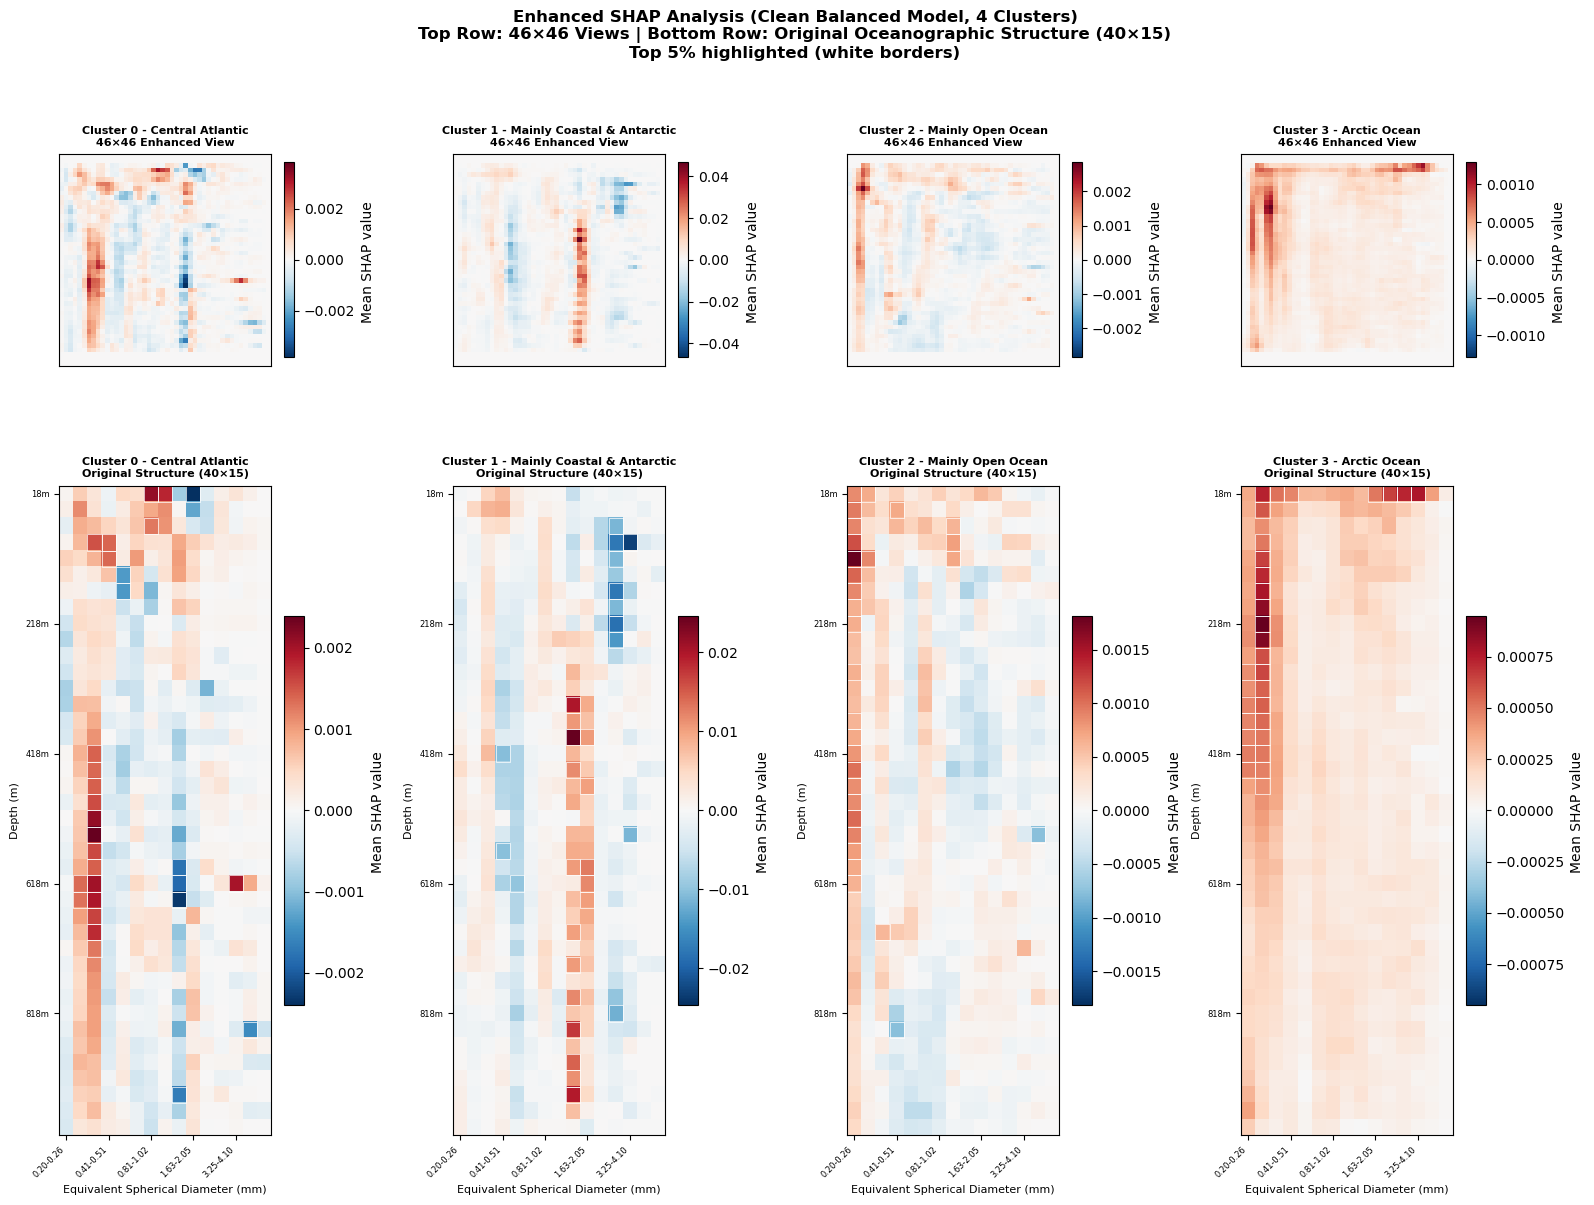


✅ Enhanced 2-row SHAP visualization completed for 4 clusters!
🎨 Created:
  1. Enhanced 2-row layout:  46×46 (top) vs 40×15 (bottom)
  2. Comparative 2-row analysis
🎯 Fixed 2-row layout for any number of clusters


In [ ]:
# Run with fixed 2-row layout for any number of clusters
cluster_shapes= run_enhanced_2row_shap_visualization()

# Transfer learning mit Resnet50

In [ ]:
# === ResNet50 Transfer-Learning quick-start (for 44×44 colorful heatmaps) ===
# Attaches the ResNet50 helper to the existing class and shows how to prepare heatmaps
# for transfer learning (Resize → preprocess_input) and build a model.

# NOTE: Subdirectories starting with a number (e.g., '3_Model') are not
# valid Python package names, so we import the helper module via file path.
import importlib.util
import sys
from pathlib import Path
import tensorflow as tf
import numpy as np

module_path = Path('resnet50_transfer.py')
if not module_path.exists():
    raise FileNotFoundError(f"ResNet helper not found at: {module_path}")

spec = importlib.util.spec_from_file_location('resnet50_transfer', str(module_path))
resnet_mod = importlib.util.module_from_spec(spec)
sys.modules['resnet50_transfer'] = resnet_mod
spec.loader.exec_module(resnet_mod)
# Grab the helper function we need
add_resnet50_methods_to_classifier = resnet_mod.add_resnet50_methods_to_classifier

# Attach (freeze_base=True initially freezes the ResNet base)
add_resnet50_methods_to_classifier(HeatmapCNNClassifier, freeze_base=True, weights='imagenet')

# Create instance and load data (only data loading/splitting/scaling steps; no training)
clf = HeatmapCNNClassifier()
clf.load_data_assignments()
clf.load_heatmaps()
clf.split_train_test()
# Note: For transfer learning, we use the raw images from clf.X_data (0..1), not the
# StandardScaler-normalized arrays (clf.X_train_scaled). Therefore we do not run clf.scale_data() here.

# Preprocessing function: resize to 224×224, optionally duplicate channels, apply ResNet preprocess_input
def preprocess_for_resnet(X, target_size=(224, 224)):
    """Converts X (numpy array with values in [0,1]) → resized & preprocessed for ResNet50"""
    # Convert to tensor
    X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
    # Scale to [0,255] because tf.keras.applications.resnet.preprocess_input expects that
    X_tf = X_tf * 255.0

    # If grayscale images with channel==1, repeat to 3 channels
    if X_tf.shape[-1] == 1:
        X_tf = tf.repeat(X_tf, repeats=3, axis=-1)

    # Resize all images to target_size
    X_resized = tf.image.resize(X_tf, target_size, method='bilinear')

    # Apply model-specific preprocessing
    X_pre = tf.keras.applications.resnet.preprocess_input(X_resized)

    return X_pre.numpy()

# Example: preprocess all existing heatmaps (can be slow for large numbers)
print(f"Existing heatmaps: {clf.X_data.shape}")
X_all_pre = preprocess_for_resnet(clf.X_data, target_size=(224, 224))
print(f"Preprocessed heatmaps shape: {X_all_pre.shape}")

# Split into train / test with the already existing data_type array
train_mask = clf.data_types == 'train'
X_train_resnet = X_all_pre[train_mask]
X_test_resnet = X_all_pre[clf.data_types == 'test']
y_train = clf.y_train_encoded if hasattr(clf, 'y_train_encoded') else None

print(f"ResNet-ready Train shape: {X_train_resnet.shape}")
print(f"ResNet-ready Test shape:  {X_test_resnet.shape}")

# Build model: Backbone + custom top
input_shape = (224, 224, 3)
base = clf.create_resnet50_backbone(input_shape, weights_local='imagenet')
model = clf.build_resnet50_classifier(base, n_classes=clf.n_classes)
model = clf.compile_resnet50_model(model, learning_rate=1e-4)

# Model summary
model.summary()

# Note: To train: model.fit(X_train_resnet, to_categorical(y_train), validation_split=0.1, ...)
# Afterwards, optionally unfreeze some base layers and fine-tune with a small LR.

ResNet50 methods attached to HeatmapCNNClassifier (freeze_base=True, weights=imagenet)
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5616 PNG files in ../Data/heatmaps
Sample filenames: ['c_msm23_048.png', 'so287_23.png', 'ctd046_1_new.png', 'azomp013.png', 'dewex_leg2_47.png']
Sample extracted profile IDs: ['c_msm23_048', 'so287_23', 'ctd046_1_new', 'azomp013', 'dewex_leg2_47']
Available profile IDs from filenames: 5616
Profile IDs with train/test data: 5619
Profile IDs with cluster data:  5619
Files matching train/test IDs: 561

Model: "resnet50_custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,640,900 (94.00 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [ ]:
# === ResNet50: Example Training (quick workflow) ===
# This example shows: 1) Training the model just created on your
# prepared ResNet inputs (X_all_pre), 2) simple validation, 3) optional
# fine-tuning of the ResNet base.

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

# Prerequisite: run previous cell with 'clf', 'X_all_pre', 'model'
try:
    clf  # classifier instance
    X_all_pre
    model
except NameError:
    raise RuntimeError("Please run the previous ResNet setup cell first (clf, X_all_pre, model must exist).")

# Training / test sets based on the already existing data_type field
train_mask = (clf.data_types == 'train')
test_mask = (clf.data_types == 'test')

X_train = X_all_pre[train_mask]
X_test = X_all_pre[test_mask]

# Labels: try to use existing encoded labels, otherwise raw labels
if hasattr(clf, 'y_train_encoded'):
    # y_train_encoded only contains values for the 'train' subset in split_train_test,
    # but here we use mask-based selection, so we extract from clf.y_data
    y_all = clf.y_data
    y_train = y_all[train_mask]
    y_test = y_all[test_mask]
else:
    # Fallback
    y_train = clf.y_data[train_mask]
    y_test = clf.y_data[test_mask]

# Encode to categorical
y_train_enc = to_categorical(y_train, num_classes=clf.n_classes)
try:
    y_test_enc = to_categorical(y_test, num_classes=clf.n_classes)
except Exception:
    y_test_enc = None

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}, Classes: {clf.n_classes}")

# Callbacks
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
ckpt = ModelCheckpoint('resnet50_best.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Basic training: train top layers (ResNet base is frozen if add_resnet50_methods_to_classifier used freeze_base=True)
history = model.fit(
    X_train,
    y_train_enc,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[es, rlp, ckpt],
    verbose=1
)

# Evaluate on test set (if test labels available)
if y_test_enc is not None and len(X_test) > 0:
    test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
    print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")
else:
    print("No test labels available or test set is empty — skipping evaluation.")

# Optional: Fine-tuning (unfreeze last conv-blocks of ResNet and re-train with small LR)
# Note: This affects training time & GPU RAM; use cautiously on small datasets.

do_finetune = True  # set to False if not desired
if do_finetune:
    print('\n=== Fine-tuning: Unfreeze last ResNet layers and train with small LR ===')
    # Find the backbone (assuming model was built with base = clf.create_resnet50_backbone())
    # The base is usually the first submodel named 'resnet50' or 'resnet50v2'.
    base_prefix = 'resnet'  # heuristic

    # Unfreeze last N layers
    N_unfreeze = 30
    unfreeze_count = 0
    for layer in model.layers[::-1]:
        # Stop when we've unfrozen N_unfreeze layers or reached the input
        if unfreeze_count >= N_unfreeze:
            break
        if not layer.trainable:
            layer.trainable = True
            unfreeze_count += 1
    print(f"Unfroze approx. {unfreeze_count} layers from the top")

    # Recompile with a much lower LR
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    # Continue training
    history_ft = model.fit(
        X_train,
        y_train_enc,
        validation_split=0.1,
        epochs=30,
        batch_size=16,
        callbacks=[es, rlp, ckpt],
        verbose=1
    )

    # Re-evaluate on test set
    if y_test_enc is not None and len(X_test) > 0:
        test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
        print(f"After fine-tuning -> Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

print('\nTraining cell completed. Check the saved checkpoint file resnet50_best.h5 for the best model.')


Train samples: 4211, Test samples: 1405, Classes: 4
Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8702 - loss: 0.3611
Epoch 1: val_loss improved from inf to 1.08789, saving model to resnet50_best.h5


237/237 ━━━━━━━━━━━━━━━━━━━━ 107s 451ms/step - accuracy: 0.8703 - loss: 0.3611 - val_accuracy: 0.6090 - val_loss: 1.0879 - learning_rate: 2.5000e-06
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9234 - loss: 0.2579
Epoch 2: val_loss did not improve from 1.08789
237/237 ━━━━━━━━━━━━━━━━━━━━ 107s 450ms/step - accuracy: 0.9234 - loss: 0.2578 - val_accuracy: 0.6209 - val_loss: 1.0911 - learning_rate: 2.5000e-06
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9403 - loss: 0.2019
Epoch 3: val_loss did not improve from 1.08789
237/237 ━━━━━━━━━━━━━━━━━━━━ 107s 451ms/step - accuracy: 0.9403 - loss: 0.2019 - val_accuracy: 0.6280 - val_loss: 1.1009 - learning_rate: 2.5000e-06
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9611 - loss: 0.1642
Epoch 4: val_loss did not improve from 1.08789
237/237 ━━━━━━━━━━━━━━━━━━━━ 109s 461ms/step - accuracy: 0.9611 - loss: 0.1642 - val_accuracy: 0.6493 - val_loss: 1.1076 - learning_rate: 2.5000e-06

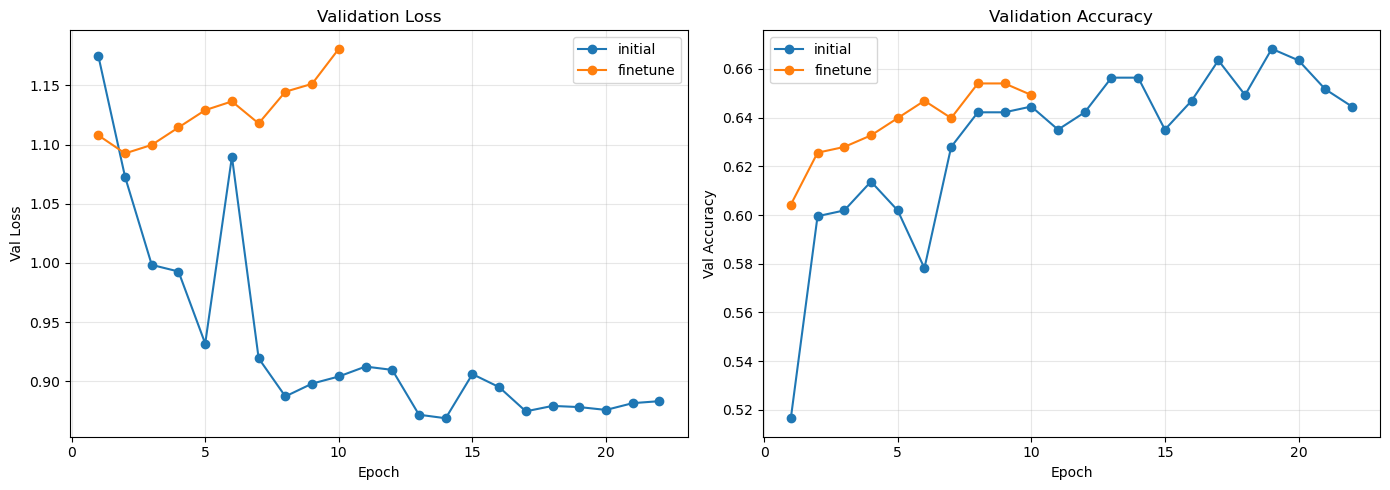

initial: best val_loss = 0.8688 at epoch 14
initial: best val_accuracy = 0.6682 at epoch 19
finetune: best val_loss = 1.0926 at epoch 2
finetune: best val_accuracy = 0.6540 at epoch 8

Saved best model: resnet50_best.h5


In [ ]:
# === Plot: Validation Loss & Validation Accuracy ===
# Plot the training history from `history` (and optionally `history_ft` if fine-tuning was run).
import matplotlib.pyplot as plt

# Collect histories
histories = []
if 'history' in globals() and hasattr(history, 'history'):
    histories.append(('initial', history.history))
if 'history_ft' in globals() and hasattr(history_ft, 'history'):
    histories.append(('finetune', history_ft.history))

if len(histories) == 0:
    print('No history objects found. Please run the training cell first.')
else:
    # Prepare combined series for plotting (concatenate if both exist)
    # For loss
    val_losses = []
    val_accs = []
    labels_losses = []
    labels_accs = []

    for tag, h in histories:
        # Common keys: 'loss','accuracy','val_loss','val_accuracy'
        if 'val_loss' in h:
            val_losses.append(h['val_loss'])
            labels_losses.append(tag)
        if 'val_accuracy' in h:
            val_accs.append(h['val_accuracy'])
            labels_accs.append(tag)
        # Compatibility: some histories might use 'val_acc'
        if 'val_acc' in h and 'val_accuracy' not in h:
            val_accs.append(h['val_acc'])
            labels_accs.append(tag)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot validation loss
    ax = axes[0]
    for seq, label in zip(val_losses, labels_losses):
        ax.plot(range(1, len(seq) + 1), seq, marker='o', label=label)
    ax.set_title('Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Loss')
    ax.grid(alpha=0.3)
    ax.legend()

    # Plot validation accuracy
    ax = axes[1]
    for seq, label in zip(val_accs, labels_accs):
        ax.plot(range(1, len(seq) + 1), seq, marker='o', label=label)
    ax.set_title('Validation Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Accuracy')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    for tag, h in histories:
        if 'val_loss' in h:
            best_epoch = int(np.argmin(h['val_loss'])) + 1
            best_val_loss = float(np.min(h['val_loss']))
            print(f"{tag}: best val_loss = {best_val_loss:.4f} at epoch {best_epoch}")
        if 'val_accuracy' in h or 'val_acc' in h:
            acc_key = 'val_accuracy' if 'val_accuracy' in h else 'val_acc'
            best_epoch_acc = int(np.argmax(h[acc_key])) + 1
            best_val_acc = float(np.max(h[acc_key]))
            print(f"{tag}: best val_accuracy = {best_val_acc:.4f} at epoch {best_epoch_acc}")

    # If ModelCheckpoint saved a file, show its path (informative)
    try:
        import os
        if os.path.exists('resnet50_best.h5'):
            print('\nSaved best model: resnet50_best.h5')
    except Exception:
        pass
